# 🧠 ML Fundamentals From Scratch — Understand Every Number Your Model Reports

> **What you'll learn:** what "learning from data" really means, why we split data three ways, loss functions, logistic regression and regularization built by hand, the bias–variance trade-off, cross-validation, every classification metric (ROC, PR, calibration), decision trees, and data leakage — each implemented in NumPy and **checked against scikit-learn**.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~6 hours to read and run, +3 hours for exercises and the project |
| **Prerequisites** | [NumPy](../01_Core_Scientific_Computing/01_NumPy.ipynb) (vectorization, broadcasting), [Math for ML](../01_Core_Scientific_Computing/04_Math_for_ML.ipynb) (derivatives, gradients), [Statistics and Probability](../01_Core_Scientific_Computing/05_Statistics_and_Probability.ipynb) (mean, variance, confidence intervals) |
| **Tested with** | Python 3.12 · numpy 2.5 · scipy 1.18 · scikit-learn 1.9 · matplotlib 3.x |
| **Interview relevance** | ⭐⭐⭐ Very high — bias–variance, L1 vs L2, "implement logistic regression / AUC from scratch", precision vs recall, threshold choice, calibration, leakage, and cross-validation are asked in almost every ML engineer loop |

## 🤔 What Is Machine Learning?

Imagine teaching a new nurse to spot suspicious tumours. You don't hand over a rulebook with thousands of if-statements — you show **examples**: "these measurements were malignant, these were benign". After enough examples, the nurse can judge a *new* case. **Machine learning (ML)** does the same with a computer: it finds a rule (a **model**) from examples, so it can make predictions on data it has never seen.

| Term | Plain English | Example (tumours) |
|---|---|---|
| **Features** `X` | the inputs we measure | radius, texture, smoothness… (30 numbers per tumour) |
| **Label / target** `y` | the answer we want to predict | malignant (1) or benign (0) |
| **Model** | a function with adjustable **parameters** | `p = sigmoid(w · x + b)` |
| **Training** | adjusting parameters to reduce a **loss** (a penalty for wrong predictions) | gradient descent on log loss |
| **Generalization** | doing well on *new* data, not just the examples we trained on | accuracy on tumours the model never saw |

- **Supervised learning** has labels: *classification* (predict a category) and *regression* (predict a number).
- **Unsupervised learning** has no labels: clustering, dimensionality reduction, anomaly detection.

```
  past examples (X, y) ──► training ──► model ──► predictions on NEW X
                                          ▲
                        the only thing that matters is how good these are
```

## 🎯 Why It Matters

- **Every ML system rests on these ideas.** Fancy models (gradient boosting, transformers, LLM fine-tuning) still need correct splits, the right loss, regularization, honest metrics, a chosen threshold, and no leakage. Most real-world ML failures are failures of *these fundamentals*, not of the model architecture.
- **Metrics drive business decisions.** A fraud model with 99% accuracy can catch zero fraud; a cancer screen needs recall, not accuracy. Knowing which number to trust is a core job skill.
- **In interviews** this is the most-tested material for ML engineers and data scientists: *"Explain bias–variance"*, *"L1 vs L2?"*, *"Why log loss and not MSE for classification?"*, *"ROC-AUC or PR-AUC for imbalanced data?"*, *"How do you pick a threshold?"*, *"Implement logistic regression / AUC in NumPy"*, *"Give examples of data leakage"*. This notebook drills every one of them with code you wrote yourself.

## ✅ By the End You Can

- [ ] Explain generalization and set up train / validation / test splits (and k-fold CV) without leakage
- [ ] Implement MSE, MAE, Huber, and log loss, and logistic regression with gradient descent — and derive its gradient
- [ ] Implement ridge (L2) and lasso (L1), and explain why L1 produces sparse models
- [ ] Diagnose under- and overfitting with the bias–variance trade-off and learning curves
- [ ] Implement confusion matrix, precision, recall, F1, ROC-AUC, average precision, reliability curves, and Brier score, and choose a threshold on validation data
- [ ] Build a depth-limited decision tree from scratch and spot data leakage in a pipeline

## 📋 Table of Contents

1. [What Learning Means: Features, Labels, Generalization](#1.-What-Learning-Means:-Features,-Labels,-Generalization-🟢)
2. [Train, Validation, and Test Splits](#2.-Train,-Validation,-and-Test-Splits-🟢)
3. [Loss Functions: MSE, MAE, Huber, Log Loss](#3.-Loss-Functions:-MSE,-MAE,-Huber,-Log-Loss-🟢)
4. [Linear Regression Recap](#4.-Linear-Regression-Recap-🟢)
5. [Logistic Regression From Scratch](#5.-Logistic-Regression-From-Scratch-🟡)
6. [Regularization: Ridge (L2) and Lasso (L1)](#6.-Regularization:-Ridge-(L2)-and-Lasso-(L1)-🟡)
7. [Bias–Variance, Overfitting, and Learning Curves](#7.-Bias–Variance,-Overfitting,-and-Learning-Curves-🟡)
8. [K-Fold Cross-Validation From Scratch](#8.-K-Fold-Cross-Validation-From-Scratch-🟡)
9. [Classification Metrics From Scratch](#9.-Classification-Metrics-From-Scratch-🟡)
10. [Class Imbalance and Threshold Tuning](#10.-Class-Imbalance-and-Threshold-Tuning-🟡)
11. [Probability Calibration](#11.-Probability-Calibration-🔴)
12. [Decision Trees: Gini, Entropy, Information Gain](#12.-Decision-Trees:-Gini,-Entropy,-Information-Gain-🟡)
13. [Feature Scaling Effects](#13.-Feature-Scaling-Effects-🟢)
14. [Data Leakage](#14.-Data-Leakage-🔴)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Malignant-Tumour-Screening-From-Scratch) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel. Two datasets are downloaded once and cached by scikit-learn (California housing ≈ 2 MB, OpenML mammography ≈ 0.5 MB).

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "numpy>=2.0" "scipy>=1.11" "scikit-learn>=1.6" "pandas>=2.2" matplotlib

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.optimize import minimize
from scipy.special import huber as scipy_huber
from scipy.stats import binomtest, rankdata
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.datasets import fetch_california_housing, fetch_openml, load_breast_cancer, load_diabetes, load_wine
from sklearn.frozen import FrozenEstimator
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (accuracy_score, average_precision_score, brier_score_loss, confusion_matrix, f1_score,
                             log_loss, mean_absolute_error, mean_squared_error, precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, learning_curve, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | SciPy {scipy.__version__} | scikit-learn {sklearn.__version__}")

rng = np.random.default_rng(42)                 # one seeded generator for the notebook
np.set_printoptions(precision=4, suppress=True)
OUTPUT_DIR = Path("_outputs")                   # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)


def check(name, got, expected, hint="", atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    try:
        g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, atol=atol, rtol=1e-5)
    except (TypeError, ValueError):
        ok = got == expected
    assert ok, f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | NumPy 2.5.3 | SciPy 1.18.1 | scikit-learn 1.9.1


## 1. What Learning Means: Features, Labels, Generalization 🟢

Our main dataset: **Wisconsin Diagnostic Breast Cancer** — 569 real tumours, 30 measurements computed from a digitized biopsy image.

⚠️ **Watch the label encoding.** In scikit-learn's copy, `target_names` is `['malignant', 'benign']`, so **target 0 = malignant and 1 = benign**. Because we care about *catching cancer*, we flip it: `y = 1` means malignant (the **positive class** — the thing we are trying to detect).

In [2]:
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = (cancer.target == 0).astype(int)     # 1 = malignant (sklearn target 0), 0 = benign

print("feature matrix:", X_cancer.shape, "| first 3 features:", cancer.feature_names[:3].tolist())
print("sklearn target names (index = code):", cancer.target_names.tolist())
print(f"malignant: {y_cancer.sum()} ({y_cancer.mean():.1%}) | benign: {(1 - y_cancer).sum()}")

feature matrix: (569, 30) | first 3 features: ['mean radius', 'mean texture', 'mean perimeter']
sklearn target names (index = code): ['malignant', 'benign']
malignant: 212 (37.3%) | benign: 357


**Memorizing is not learning.** A decision tree grown until every leaf is pure can memorize the training set perfectly. What matters is accuracy on tumours it has *not* seen.

In [3]:
shuffled = rng.permutation(len(y_cancer))
seen, unseen = shuffled[:400], shuffled[400:]

memorizer = DecisionTreeClassifier(random_state=0).fit(X_cancer[seen], y_cancer[seen])          # no depth limit
simple = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_cancer[seen], y_cancer[seen])

for name, model in [("fully grown tree", memorizer), ("logistic regression", simple)]:
    print(f"{name:20s} accuracy on SEEN data {model.score(X_cancer[seen], y_cancer[seen]):.3f}"
          f" | on UNSEEN data {model.score(X_cancer[unseen], y_cancer[unseen]):.3f}")

fully grown tree     accuracy on SEEN data 1.000 | on UNSEEN data 0.923
logistic regression  accuracy on SEEN data 0.988 | on UNSEEN data 0.982


The tree scores a perfect 1.000 on data it has seen — that number tells you nothing about the future. The gap between "seen" and "unseen" performance is the **generalization gap**.

### ✍️ Your Turn

Compute `n_features` (number of columns in `X_cancer`) and `malignant_rate` (fraction of tumours that are malignant, using `y_cancer`).

In [4]:
n_features = None      # TODO
malignant_rate = None  # TODO
check("n_features", n_features, 30, hint="X_cancer.shape[1]")
check("malignant_rate", malignant_rate, 212 / 569, hint="The mean of a 0/1 array is the fraction of 1s.")

⏳ n_features: not attempted yet — replace None with your answer.
⏳ malignant_rate: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_features = X_cancer.shape[1]
malignant_rate = y_cancer.mean()
check("n_features", n_features, 30)
check("malignant_rate", malignant_rate, 212 / 569)
```
If you had used `cancer.target.mean()` you would get the **benign** rate (0.627) — the classic label-flip bug.
</details>

> 💡 **Interview angle:** "What is generalization?" — performance on new data from the same distribution. Training error is optimistic by construction; you estimate generalization with held-out data.

## 2. Train, Validation, and Test Splits 🟢

| Split | Used for | Analogy |
|---|---|---|
| **Train** (~60–80%) | fitting the model's parameters | studying from the textbook |
| **Validation** (~10–20%) | choosing hyperparameters, features, thresholds, which model | practice exams |
| **Test** (~10–20%) | **one** final, unbiased estimate | the real exam — taken once |

**Why three and not two?** Every decision you make by looking at a score "fits" that data a little. If you choose among many options using the test set, the test score is no longer an honest estimate of the future.

**Stratified** splitting keeps the class ratio the same in every split — important for small or imbalanced datasets.

In [5]:
def train_val_test_split(n, val_frac=0.2, test_frac=0.2, seed=0, stratify=None):
    """Return shuffled index arrays (train, val, test). If `stratify` is given, split each class separately."""
    gen = np.random.default_rng(seed)
    groups = [np.arange(n)] if stratify is None else [np.flatnonzero(stratify == c) for c in np.unique(stratify)]
    train, val, test = [], [], []
    for group in groups:
        idx = gen.permutation(group)
        n_test, n_val = int(round(len(idx) * test_frac)), int(round(len(idx) * val_frac))
        test.append(idx[:n_test])
        val.append(idx[n_test:n_test + n_val])
        train.append(idx[n_test + n_val:])
    return tuple(gen.permutation(np.concatenate(part)) for part in (train, val, test))


tr_idx, va_idx, te_idx = train_val_test_split(len(y_cancer), seed=42, stratify=y_cancer)
assert len(np.intersect1d(tr_idx, va_idx)) == len(np.intersect1d(tr_idx, te_idx)) == len(np.intersect1d(va_idx, te_idx)) == 0
assert len(np.union1d(np.union1d(tr_idx, va_idx), te_idx)) == len(y_cancer)
for name, idx in [("train", tr_idx), ("validation", va_idx), ("test", te_idx)]:
    print(f"{name:10s}: {len(idx):3d} rows | malignant rate {y_cancer[idx].mean():.3f}")

# sklearn's stratified split gives the same proportions (different rows)
_, sk_test = train_test_split(np.arange(len(y_cancer)), test_size=0.2, stratify=y_cancer, random_state=42)
print(f"sklearn stratified test split: {len(sk_test)} rows | malignant rate {y_cancer[sk_test].mean():.3f}")

train     : 343 rows | malignant rate 0.373
validation: 113 rows | malignant rate 0.372
test      : 113 rows | malignant rate 0.372
sklearn stratified test split: 114 rows | malignant rate 0.368


**Seeing the danger of choosing on the test set.** Below we build 2,000 deliberately simple "models" (a single feature above a threshold → malignant), pick the one with the best **selection-set** accuracy, and compare with its accuracy on fresh data. We repeat it for 30 different random splits.

In [6]:
def stump_accuracy(X_part, y_part, features, thresholds, flips):
    """Accuracy of many one-feature rules at once: predict 1 when X[feature] >= threshold (or < if flipped)."""
    pred = (X_part[:, features] >= thresholds) ^ flips          # (n_samples, n_rules)
    return (pred == y_part[:, None]).mean(axis=0)


optimism = []
for split_seed in range(30):
    a, b, c = train_val_test_split(len(y_cancer), seed=split_seed, stratify=y_cancer)
    gen = np.random.default_rng(split_seed)
    features = gen.integers(0, X_cancer.shape[1], 2000)
    thresholds = np.quantile(X_cancer[a], gen.uniform(0.05, 0.95, 2000), axis=0)[np.arange(2000), features]
    flips = gen.random(2000) < 0.5
    select_acc = stump_accuracy(X_cancer[b], y_cancer[b], features, thresholds, flips)
    fresh_acc = stump_accuracy(X_cancer[c], y_cancer[c], features, thresholds, flips)
    winner = select_acc.argmax()
    optimism.append(select_acc[winner] - fresh_acc[winner])

optimism = np.array(optimism)
print(f"winner's accuracy on the set used to choose it is higher than on fresh data by {optimism.mean():+.3f} on average "
      f"(positive in {np.mean(optimism > 0):.0%} of 30 splits)")

winner's accuracy on the set used to choose it is higher than on fresh data by +0.039 on average (positive in 87% of 30 splits)


That optimism is why the set you **choose with** (validation) must be different from the set you **report** (test).

### ✍️ Your Turn

Use `train_val_test_split` to make a **stratified 70 / 15 / 15** split of the cancer data with `seed=7`. Store the three index arrays in `tr7, va7, te7`.

In [7]:
tr7 = va7 = te7 = None  # TODO
check("split_sizes", None if tr7 is None else [len(tr7), len(va7), len(te7)], [397, 86, 86],
      hint="val_frac=0.15, test_frac=0.15, stratify=y_cancer — rounding happens per class.")

⏳ split_sizes: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tr7, va7, te7 = train_val_test_split(len(y_cancer), val_frac=0.15, test_frac=0.15, seed=7, stratify=y_cancer)
check("split_sizes", [len(tr7), len(va7), len(te7)], [397, 86, 86])
```
Per class: malignant 212 → 32 test, 32 val, 148 train; benign 357 → 54, 54, 249.
</details>

> 💡 **Interview angle:** "Why not just tune on the test set?" — selecting the best of many options on a set makes that set's score optimistically biased (the winner's curse). Keep the test set for one final number; use validation or cross-validation for every choice.

## 3. Loss Functions: MSE, MAE, Huber, Log Loss 🟢

A **loss function** turns "how wrong is the prediction?" into one number that training can minimize. With residual $r = y - \hat y$:

| Loss | Formula (per example) | Behaviour | Best constant prediction |
|---|---|---|---|
| **MSE** (mean squared error) | $r^2$ | punishes big errors hard → sensitive to outliers | the **mean** |
| **MAE** (mean absolute error) | $\lvert r \rvert$ | every unit of error costs the same → robust | the **median** |
| **Huber** (δ) | $\tfrac12 r^2$ if $\lvert r\rvert \le δ$, else $δ(\lvert r\rvert - \tfrac12 δ)$ | MSE near 0, MAE for big errors | between mean and median |
| **Log loss** (binary cross-entropy) | $-[y \log p + (1-y)\log(1-p)]$ | for probabilities; huge penalty for confident wrong answers | the class frequency |

In [8]:
def mse(y, y_hat):
    return float(np.mean((y - y_hat) ** 2))


def mae(y, y_hat):
    return float(np.mean(np.abs(y - y_hat)))


def huber(y, y_hat, delta=1.0):
    r = np.abs(y - y_hat)
    return float(np.mean(np.where(r <= delta, 0.5 * r ** 2, delta * (r - 0.5 * delta))))


def binary_log_loss(y, p, eps=1e-15):
    p = np.clip(p, eps, 1 - eps)                               # avoid log(0) = -inf
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))


y_demo = np.array([3.0, -0.5, 2.0, 7.0])
y_hat_demo = np.array([2.5, 0.0, 2.0, 8.0])
assert np.isclose(mse(y_demo, y_hat_demo), mean_squared_error(y_demo, y_hat_demo))
assert np.isclose(mae(y_demo, y_hat_demo), mean_absolute_error(y_demo, y_hat_demo))
assert np.isclose(huber(y_demo, y_hat_demo, 1.0), scipy_huber(1.0, y_demo - y_hat_demo).mean())
labels_demo, probs_demo = np.array([1, 0, 1, 1, 0]), np.array([0.9, 0.2, 0.6, 0.99, 0.4])
assert np.isclose(binary_log_loss(labels_demo, probs_demo), log_loss(labels_demo, probs_demo))
print("✅ MSE, MAE (sklearn), Huber (scipy), and log loss (sklearn) all match")

✅ MSE, MAE (sklearn), Huber (scipy), and log loss (sklearn) all match


**Outlier sensitivity on real data.** Diabetes progression scores (442 patients): which single constant minimizes each loss?

In [9]:
y_diab_raw = load_diabetes().target
candidates = np.linspace(y_diab_raw.min(), y_diab_raw.max(), 4001)
best = {name: candidates[np.argmin([fn(y_diab_raw, c) for c in candidates])]
        for name, fn in [("MSE", mse), ("MAE", mae), ("Huber δ=50", lambda y, c: huber(y, c, 50.0))]}
print({k: round(float(v), 1) for k, v in best.items()})
print(f"mean = {y_diab_raw.mean():.1f} | median = {np.median(y_diab_raw):.1f}")
assert abs(best["MSE"] - y_diab_raw.mean()) < 0.2 and abs(best["MAE"] - np.median(y_diab_raw)) <= 1.0

{'MSE': 152.1, 'MAE': 140.1, 'Huber δ=50': 141.1}
mean = 152.1 | median = 140.5


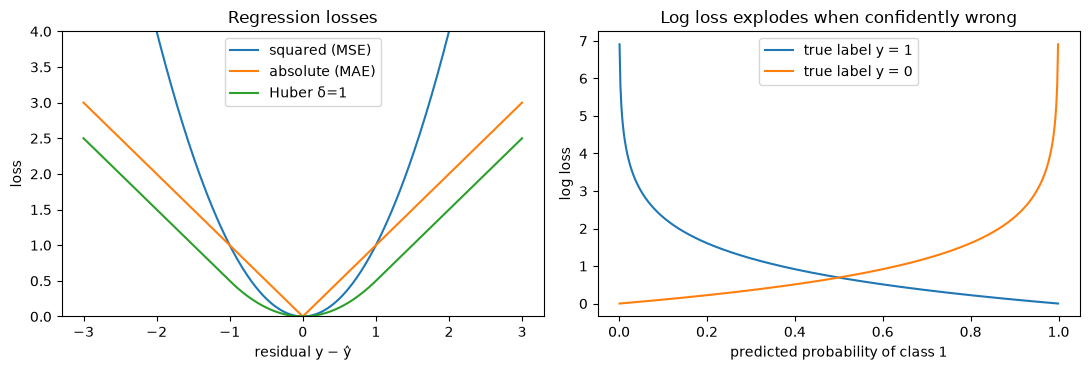

true label 1, predicted p = 0.9  → log loss 0.11
true label 1, predicted p = 0.6  → log loss 0.51
true label 1, predicted p = 0.1  → log loss 2.30
true label 1, predicted p = 0.01 → log loss 4.61


In [10]:
residuals = np.linspace(-3, 3, 301)
p_grid = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(residuals, residuals ** 2, label="squared (MSE)")
axes[0].plot(residuals, np.abs(residuals), label="absolute (MAE)")
axes[0].plot(residuals, scipy_huber(1.0, residuals), label="Huber δ=1")
axes[0].set(xlabel="residual y − ŷ", ylabel="loss", title="Regression losses", ylim=(0, 4))
axes[0].legend()
axes[1].plot(p_grid, -np.log(p_grid), label="true label y = 1")
axes[1].plot(p_grid, -np.log(1 - p_grid), label="true label y = 0")
axes[1].set(xlabel="predicted probability of class 1", ylabel="log loss", title="Log loss explodes when confidently wrong")
axes[1].legend()
plt.tight_layout()
plt.show()

for p in [0.9, 0.6, 0.1, 0.01]:
    print(f"true label 1, predicted p = {p:<4} → log loss {-np.log(p):.2f}")

### ✍️ Your Turn

Compute the **log loss** of `p_turn` for labels `y_turn` *without* calling scikit-learn (use NumPy only).

In [11]:
y_turn = np.array([1, 1, 0, 0, 1])
p_turn = np.array([0.8, 0.3, 0.1, 0.6, 0.95])
my_log_loss = None  # TODO
check("log_loss", my_log_loss, log_loss(y_turn, p_turn), hint="-mean(y*log(p) + (1-y)*log(1-p))")

⏳ log_loss: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_turn = np.array([1, 1, 0, 0, 1])
p_turn = np.array([0.8, 0.3, 0.1, 0.6, 0.95])
my_log_loss = -np.mean(y_turn * np.log(p_turn) + (1 - y_turn) * np.log(1 - p_turn))
check("log_loss", my_log_loss, log_loss(y_turn, p_turn))
```
The 0.3 for a true positive and the 0.6 for a true negative contribute most of the loss.
</details>

> 💡 **Interview angle:** "MSE or MAE?" — MSE if big errors are disproportionately bad and noise is roughly Gaussian (it estimates the conditional **mean**); MAE if outliers are common or you want the **median**; Huber for a compromise that is still smooth near zero.

## 4. Linear Regression Recap 🟢

You built linear regression in the NumPy notebook. One-line recap: the model is $\hat y = Xw + b$, it minimizes MSE, and the exact solution is least squares (`np.linalg.lstsq`). Here we run it on **California housing** (20,640 districts, median house value in $100k) and confirm it matches scikit-learn.

In [12]:
housing = fetch_california_housing()
X_house, y_house = housing.data, housing.target
h_tr, h_va, h_te = train_val_test_split(len(y_house), seed=0)
h_mu, h_sd = X_house[h_tr].mean(axis=0), X_house[h_tr].std(axis=0)      # statistics from TRAIN only


def standardize(X):
    return (X - h_mu) / h_sd


design_tr = np.column_stack([np.ones(len(h_tr)), standardize(X_house[h_tr])])
w_ls, *_ = np.linalg.lstsq(design_tr, y_house[h_tr], rcond=None)
pred_va = np.column_stack([np.ones(len(h_va)), standardize(X_house[h_va])]) @ w_ls

sk_lin = LinearRegression().fit(standardize(X_house[h_tr]), y_house[h_tr])
assert np.allclose(w_ls[1:], sk_lin.coef_) and np.isclose(w_ls[0], sk_lin.intercept_)

print(f"validation RMSE: linear regression {np.sqrt(mse(y_house[h_va], pred_va)):.3f}"
      f" | always-predict-train-mean baseline {np.sqrt(mse(y_house[h_va], np.full(len(h_va), y_house[h_tr].mean()))):.3f}")
print("largest standardized weights:", dict(sorted(zip(housing.feature_names, w_ls[1:].round(2).tolist()), key=lambda kv: -abs(kv[1]))[:3]))

validation RMSE: linear regression 0.751 | always-predict-train-mean baseline 1.158
largest standardized weights: {'Latitude': -0.91, 'Longitude': -0.89, 'MedInc': 0.8}


> 💡 **Interview angle:** "What does a linear regression coefficient mean?" — the change in prediction for a one-unit (here: one standard deviation) change in that feature *holding the others fixed*. With correlated features (e.g. latitude and longitude, rooms and bedrooms) individual coefficients are unstable, which is one reason to regularize.

## 5. Logistic Regression From Scratch 🟡

Logistic regression is linear regression passed through a squashing function so the output is a **probability**:

$$z = w \cdot x + b, \qquad p = \sigma(z) = \frac{1}{1 + e^{-z}}$$

**Training objective** (mean log loss + optional L2 penalty, the bias is not penalized):

$$L(w, b) = \frac{1}{n}\sum_i \Big[-y_i \log p_i - (1-y_i)\log(1-p_i)\Big] + \frac{\lambda}{2}\lVert w \rVert^2$$

**The gradient in three lines** (this derivation is a classic interview question):
1. $\dfrac{d\sigma}{dz} = \sigma(z)\,(1-\sigma(z)) = p(1-p)$
2. For one example, $\dfrac{\partial \ell}{\partial p} = -\dfrac{y}{p} + \dfrac{1-y}{1-p} = \dfrac{p-y}{p(1-p)}$, so by the chain rule $\dfrac{\partial \ell}{\partial z} = \dfrac{p-y}{p(1-p)} \cdot p(1-p) = p - y$
3. Since $\partial z / \partial w = x$: $\quad \nabla_w L = \dfrac{1}{n} X^\top (p - y) + \lambda w, \qquad \dfrac{\partial L}{\partial b} = \dfrac{1}{n}\sum_i (p_i - y_i)$

The $p(1-p)$ terms cancel — that is why log loss and the sigmoid are such a good pair (with MSE they don't cancel, and gradients vanish when the model is confidently wrong).

In [13]:
def sigmoid(z):
    """Numerically stable sigmoid: never computes exp of a large positive number."""
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out


def logistic_loss_and_grad(X, y, w, b, lam=0.0, sample_weight=None):
    """Mean (optionally weighted) log loss + L2 penalty, and its gradients."""
    s = np.ones(len(y)) if sample_weight is None else sample_weight
    z = X @ w + b
    loss = np.mean(s * (np.logaddexp(0, z) - y * z)) + 0.5 * lam * (w @ w)   # log(1+e^z) - y·z == log loss, stably
    err = s * (sigmoid(z) - y)                                             # dLoss/dz = p - y
    return loss, X.T @ err / len(y) + lam * w, err.mean()


# Standardize with TRAIN statistics (section 13 explains why scaling matters for gradient descent)
c_mu, c_sd = X_cancer[tr_idx].mean(axis=0), X_cancer[tr_idx].std(axis=0)
Xc_tr, Xc_va, Xc_te = [(X_cancer[idx] - c_mu) / c_sd for idx in (tr_idx, va_idx, te_idx)]
yc_tr, yc_va, yc_te = y_cancer[tr_idx], y_cancer[va_idx], y_cancer[te_idx]

# Gradient check: compare the analytic gradient with finite differences (always do this for hand-written gradients)
w_try, b_try, eps = rng.normal(scale=0.1, size=Xc_tr.shape[1]), 0.2, 1e-6
_, grad_w, grad_b = logistic_loss_and_grad(Xc_tr, yc_tr, w_try, b_try, lam=0.01)
numeric_w = np.array([(logistic_loss_and_grad(Xc_tr, yc_tr, w_try + eps * e, b_try, 0.01)[0]
                       - logistic_loss_and_grad(Xc_tr, yc_tr, w_try - eps * e, b_try, 0.01)[0]) / (2 * eps)
                      for e in np.eye(len(w_try))])
assert np.allclose(grad_w, numeric_w, atol=1e-6)
print(f"✅ analytic gradient matches finite differences (max diff {np.abs(grad_w - numeric_w).max():.1e})")

✅ analytic gradient matches finite differences (max diff 1.7e-10)


✅ converged in 2218 epochs; weights match sklearn (max diff 1.0e-06)
validation: accuracy 0.947 | log loss 0.1106


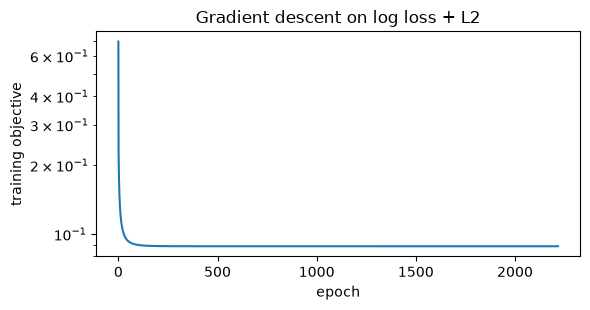

In [14]:
def fit_logistic(X, y, lam=0.0, lr=0.5, max_epochs=20_000, tol=1e-8, sample_weight=None):
    """Batch gradient descent. Stops when every gradient component is below `tol`."""
    w, b = np.zeros(X.shape[1]), 0.0
    history = []
    for _ in range(max_epochs):
        loss, grad_w, grad_b = logistic_loss_and_grad(X, y, w, b, lam, sample_weight)
        history.append(loss)
        if max(np.abs(grad_w).max(), abs(grad_b)) < tol:
            break
        w -= lr * grad_w
        b -= lr * grad_b
    return w, b, np.array(history)


LAM = 0.01
w_log, b_log, loss_history = fit_logistic(Xc_tr, yc_tr, lam=LAM)

# scikit-learn minimizes  C · Σ log loss + ½‖w‖²  →  identical optimum when C = 1 / (λ · n)
sk_log = LogisticRegression(C=1 / (LAM * len(yc_tr)), tol=1e-10, max_iter=10_000).fit(Xc_tr, yc_tr)
assert np.allclose(w_log, sk_log.coef_[0], atol=1e-4) and np.isclose(b_log, sk_log.intercept_[0], atol=1e-4)
p_va_log = sigmoid(Xc_va @ w_log + b_log)
assert np.allclose(p_va_log, sk_log.predict_proba(Xc_va)[:, 1], atol=1e-4)
print(f"✅ converged in {len(loss_history)} epochs; weights match sklearn (max diff {np.abs(w_log - sk_log.coef_[0]).max():.1e})")
print(f"validation: accuracy {np.mean((p_va_log >= 0.5) == yc_va):.3f} | log loss {binary_log_loss(yc_va, p_va_log):.4f}")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(loss_history)
ax.set(xlabel="epoch", ylabel="training objective", yscale="log", title="Gradient descent on log loss + L2")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

For the tiny dataset below, compute `grad_zero`: the gradient of the **mean log loss** (no penalty) with respect to `w` at `w = 0, b = 0`, using the formula $\frac{1}{n}X^\top(p - y)$. The checker compares it with a finite-difference estimate.

In [15]:
X_tiny = np.array([[1.0, 2.0], [0.5, -1.0], [-1.5, 0.0]])
y_tiny = np.array([1.0, 0.0, 1.0])
grad_zero = None  # TODO
numeric_zero = np.array([(logistic_loss_and_grad(X_tiny, y_tiny, 1e-6 * e, 0.0)[0] - logistic_loss_and_grad(X_tiny, y_tiny, -1e-6 * e, 0.0)[0]) / 2e-6
                         for e in np.eye(2)])
check("grad_zero", grad_zero, numeric_zero, hint="At w=0, b=0 every p is sigmoid(0) = 0.5.")

⏳ grad_zero: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_tiny = np.array([[1.0, 2.0], [0.5, -1.0], [-1.5, 0.0]])
y_tiny = np.array([1.0, 0.0, 1.0])
p = sigmoid(X_tiny @ np.zeros(2) + 0.0)            # all 0.5
grad_zero = X_tiny.T @ (p - y_tiny) / len(y_tiny)
numeric_zero = np.array([(logistic_loss_and_grad(X_tiny, y_tiny, 1e-6 * e, 0.0)[0] - logistic_loss_and_grad(X_tiny, y_tiny, -1e-6 * e, 0.0)[0]) / 2e-6 for e in np.eye(2)])
check("grad_zero", grad_zero, numeric_zero)
```
</details>

> 💡 **Interview angle:** "Derive the gradient of logistic regression" — say the three steps: σ' = p(1−p), ∂ℓ/∂z = p − y (the p(1−p) cancels), ∇w = Xᵀ(p − y)/n. Then mention you would verify it with a finite-difference gradient check.

## 6. Regularization: Ridge (L2) and Lasso (L1) 🟡

**Regularization** adds a penalty for large weights, trading a little training fit for a simpler, more stable model.

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty | $\alpha \sum_j w_j^2$ | $\alpha \sum_j \lvert w_j \rvert$ |
| Effect | shrinks all weights smoothly toward 0 | sets many weights **exactly** to 0 → feature selection |
| Solution | closed form $w = (X^\top X + \alpha I)^{-1} X^\top y$ | no closed form → coordinate descent / proximal gradient |
| Correlated features | spreads weight across them | tends to pick one |

⚠️ Scikit-learn's scales differ: `Ridge` minimizes $\lVert y - Xw\rVert^2 + \alpha\lVert w\rVert^2$ (a **sum**), `Lasso` minimizes $\frac{1}{2n}\lVert y - Xw\rVert^2 + \alpha\lVert w\rVert_1$ (a **mean**). The intercept is never penalized — we handle it by centering X and y.

We use the **diabetes** dataset (442 patients, 10 standardized features). This section studies *coefficients*, so we fit on all rows.

In [16]:
diabetes = load_diabetes(scaled=False)
X_diab = (diabetes.data - diabetes.data.mean(axis=0)) / diabetes.data.std(axis=0)
y_diab = diabetes.target
DIAB_FEATURES = diabetes.feature_names


def ridge_closed_form(X, y, alpha):
    x_mean, y_mean = X.mean(axis=0), y.mean()
    Xc, yc = X - x_mean, y - y_mean
    w = np.linalg.solve(Xc.T @ Xc + alpha * np.eye(X.shape[1]), Xc.T @ yc)
    return w, y_mean - x_mean @ w


def soft_threshold(rho, lam):
    """argmin_w ½(w - rho)² + lam·|w|  — shrink toward 0 by lam, and snap to exactly 0 inside [-lam, lam]."""
    return np.sign(rho) * np.maximum(np.abs(rho) - lam, 0.0)


def lasso_coordinate_descent(X, y, alpha, max_iter=10_000, tol=1e-10):
    """Minimize 1/(2n)·||y - Xw - b||² + alpha·||w||₁ one coordinate at a time."""
    n, d = X.shape
    x_mean, y_mean = X.mean(axis=0), y.mean()
    Xc, residual = X - x_mean, y - y_mean                # residual = y - Xw with w = 0
    col_sq = (Xc ** 2).sum(axis=0) / n
    w = np.zeros(d)
    for _ in range(max_iter):
        biggest_step = 0.0
        for j in range(d):
            rho = Xc[:, j] @ (residual + Xc[:, j] * w[j]) / n          # correlation of feature j with the partial residual
            new_wj = soft_threshold(rho, alpha) / col_sq[j]
            if new_wj != w[j]:
                residual -= Xc[:, j] * (new_wj - w[j])
                biggest_step = max(biggest_step, abs(new_wj - w[j]))
                w[j] = new_wj
        if biggest_step < tol:
            break
    return w, y_mean - x_mean @ w


for alpha in [0.1, 10.0, 1000.0]:
    w_r, b_r = ridge_closed_form(X_diab, y_diab, alpha)
    sk_r = Ridge(alpha=alpha).fit(X_diab, y_diab)
    assert np.allclose(w_r, sk_r.coef_) and np.isclose(b_r, sk_r.intercept_)
for alpha in [0.1, 1.0, 5.0, 20.0]:
    w_l, b_l = lasso_coordinate_descent(X_diab, y_diab, alpha)
    sk_l = Lasso(alpha=alpha, tol=1e-12, max_iter=100_000).fit(X_diab, y_diab)
    assert np.allclose(w_l, sk_l.coef_, atol=1e-6) and np.isclose(b_l, sk_l.intercept_, atol=1e-6)
    print(f"lasso α={alpha:<5}: {int((w_l == 0).sum())} of 10 weights exactly zero (sklearn: {int((sk_l.coef_ == 0).sum())})")
print("✅ ridge closed form and lasso coordinate descent match scikit-learn")

lasso α=0.1  : 1 of 10 weights exactly zero (sklearn: 1)
lasso α=1.0  : 3 of 10 weights exactly zero (sklearn: 3)
lasso α=5.0  : 5 of 10 weights exactly zero (sklearn: 5)
lasso α=20.0 : 7 of 10 weights exactly zero (sklearn: 7)
✅ ridge closed form and lasso coordinate descent match scikit-learn


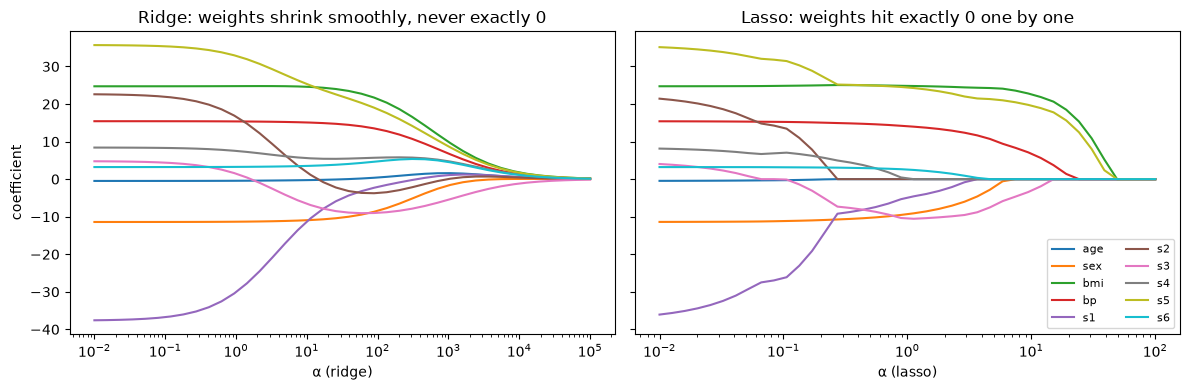

exact zeros along the path — ridge: 0 | lasso: 139
features lasso keeps at α≈10: ['bmi', 'bp', 's3', 's5']


In [17]:
ridge_alphas, lasso_alphas = np.logspace(-2, 5, 40), np.logspace(-2, 2, 40)
ridge_path = np.array([ridge_closed_form(X_diab, y_diab, a)[0] for a in ridge_alphas])
lasso_path = np.array([lasso_coordinate_descent(X_diab, y_diab, a, tol=1e-8)[0] for a in lasso_alphas])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for j, name in enumerate(DIAB_FEATURES):
    axes[0].plot(ridge_alphas, ridge_path[:, j], label=name)
    axes[1].plot(lasso_alphas, lasso_path[:, j], label=name)
axes[0].set(xscale="log", xlabel="α (ridge)", ylabel="coefficient", title="Ridge: weights shrink smoothly, never exactly 0")
axes[1].set(xscale="log", xlabel="α (lasso)", title="Lasso: weights hit exactly 0 one by one")
axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

print("exact zeros along the path — ridge:", int((ridge_path == 0).sum()), "| lasso:", int((lasso_path == 0).sum()))
survivors = [DIAB_FEATURES[j] for j in np.flatnonzero(lasso_path[np.searchsorted(lasso_alphas, 10.0)] != 0)]
print("features lasso keeps at α≈10:", survivors)

**Why does L1 give exact zeros?** Look at one weight at a time. The L2 penalty's pull toward zero is $2\alpha w$ — it gets *weaker* as $w$ gets small, so the weight approaches 0 but never lands on it. The L1 penalty pulls with a **constant** force $\alpha$ no matter how small $w$ is; if the data's pull on a feature ($\rho$ above) is weaker than $\alpha$, the best value is exactly 0 — that is the `soft_threshold`. Geometrically, the L1 constraint region is a diamond whose **corners sit on the axes**, and the loss contours usually touch it at a corner.

### ✍️ Your Turn

Implement the soft-threshold operator yourself (don't call `soft_threshold`) for `rho_turn` with `lam = 1.0`.

In [18]:
rho_turn = np.array([-3.0, -0.5, 0.0, 0.8, 2.5])
shrunk = None  # TODO
check("soft_threshold", shrunk, [-2.0, 0.0, 0.0, 0.0, 1.5], hint="sign(rho) * max(|rho| - lam, 0)")

⏳ soft_threshold: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
rho_turn = np.array([-3.0, -0.5, 0.0, 0.8, 2.5])
shrunk = np.sign(rho_turn) * np.maximum(np.abs(rho_turn) - 1.0, 0.0)
check("soft_threshold", shrunk, [-2.0, 0.0, 0.0, 0.0, 1.5])
```
Every value inside [−1, 1] becomes exactly 0; everything else moves 1 unit toward 0.
</details>

> 💡 **Interview angle:** "L1 vs L2?" — L2 shrinks all weights and handles correlated features gracefully (and has a closed form); L1 produces sparse models (built-in feature selection) because its constant pull snaps small weights to zero. Elastic net mixes both. Always standardize features first, or the penalty punishes features just for their units.

## 7. Bias–Variance, Overfitting, and Learning Curves 🟡

Expected error on new data splits into three parts:

$$\mathbb{E}\big[(y - \hat f(x))^2\big] = \underbrace{\big(\mathbb{E}[\hat f(x)] - f(x)\big)^2}_{\text{bias}^2} + \underbrace{\operatorname{Var}\big[\hat f(x)\big]}_{\text{variance}} + \underbrace{\sigma^2}_{\text{noise}}$$

- **Bias** — error from wrong assumptions (a straight line for a curve). High bias → **underfitting**: bad on train *and* validation.
- **Variance** — how much the fitted model changes when the training data changes. High variance → **overfitting**: great on train, bad on validation.
- **Noise** — randomness no model can remove.

Measuring bias and variance requires knowing the *true* function, so this first experiment uses **synthetic data** (a sine curve plus noise) on purpose: we fit polynomials of increasing degree to 300 freshly-drawn noisy training sets.

In [19]:
def true_curve(x):
    return np.sin(2 * np.pi * x)


x_fixed = np.linspace(0, 1, 30)                     # fixed input locations; only the noise changes between datasets
NOISE_SD, N_DATASETS = 0.3, 300
bv_rows = []
for degree in [1, 2, 3, 4, 5, 7, 9, 12]:
    preds, train_err, new_err = np.empty((N_DATASETS, len(x_fixed))), [], []
    for k in range(N_DATASETS):
        y_noisy = true_curve(x_fixed) + rng.normal(0, NOISE_SD, len(x_fixed))
        coefs = np.polynomial.polynomial.polyfit(x_fixed, y_noisy, degree)
        preds[k] = np.polynomial.polynomial.polyval(x_fixed, coefs)
        train_err.append(mse(y_noisy, preds[k]))
        new_err.append(mse(true_curve(x_fixed) + rng.normal(0, NOISE_SD, len(x_fixed)), preds[k]))   # fresh noise = new data
    bv_rows.append({"degree": degree, "bias²": np.mean((preds.mean(axis=0) - true_curve(x_fixed)) ** 2),
                    "variance": preds.var(axis=0).mean(), "train MSE": np.mean(train_err), "new-data MSE": np.mean(new_err)})

bv = pd.DataFrame(bv_rows).set_index("degree")
bv["bias²+var+noise"] = bv["bias²"] + bv["variance"] + NOISE_SD ** 2
print(bv.round(4).to_string())
print(f"\nlowest new-data error at degree {bv['new-data MSE'].idxmin()}; the decomposition matches the measured error "
      f"within {np.abs(bv['bias²+var+noise'] - bv['new-data MSE']).max():.3f}")

         bias²  variance  train MSE  new-data MSE  bias²+var+noise
degree                                                            
1       0.2197    0.0061     0.3067        0.3169           0.3158
2       0.2198    0.0090     0.2998        0.3165           0.3187
3       0.0056    0.0114     0.0840        0.1071           0.1071
4       0.0056    0.0149     0.0810        0.1126           0.1105
5       0.0001    0.0180     0.0725        0.1086           0.1081
7       0.0001    0.0241     0.0672        0.1140           0.1142
9       0.0001    0.0296     0.0608        0.1219           0.1197
12      0.0002    0.0390     0.0518        0.1314           0.1291

lowest new-data error at degree 3; the decomposition matches the measured error within 0.002


Now the same trade-off on **real data**: decision trees of increasing depth on California housing. Depth is the complexity knob.

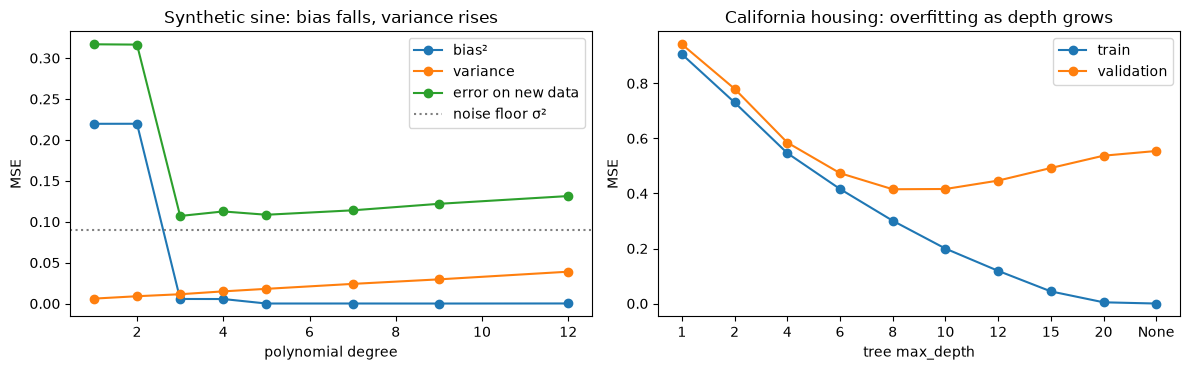

best validation MSE 0.415 at max_depth=8; the unlimited tree has train MSE 0.000 but validation 0.554


In [20]:
depth_rows = []
for depth in [1, 2, 4, 6, 8, 10, 12, 15, 20, None]:
    tree_reg = DecisionTreeRegressor(max_depth=depth, random_state=0).fit(X_house[h_tr], y_house[h_tr])
    depth_rows.append({"max_depth": "None" if depth is None else depth,
                       "train MSE": mse(y_house[h_tr], tree_reg.predict(X_house[h_tr])),
                       "validation MSE": mse(y_house[h_va], tree_reg.predict(X_house[h_va]))})
depth_df = pd.DataFrame(depth_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(bv.index, bv["bias²"], "o-", label="bias²")
axes[0].plot(bv.index, bv["variance"], "o-", label="variance")
axes[0].plot(bv.index, bv["new-data MSE"], "o-", label="error on new data")
axes[0].axhline(NOISE_SD ** 2, ls=":", c="grey", label="noise floor σ²")
axes[0].set(xlabel="polynomial degree", ylabel="MSE", title="Synthetic sine: bias falls, variance rises")
axes[0].legend()
axes[1].plot(depth_df["max_depth"].astype(str), depth_df["train MSE"], "o-", label="train")
axes[1].plot(depth_df["max_depth"].astype(str), depth_df["validation MSE"], "o-", label="validation")
axes[1].set(xlabel="tree max_depth", ylabel="MSE", title="California housing: overfitting as depth grows")
axes[1].legend()
plt.tight_layout()
plt.show()

best_depth_row = depth_df.loc[depth_df["validation MSE"].idxmin()]
print(f"best validation MSE {best_depth_row['validation MSE']:.3f} at max_depth={best_depth_row['max_depth']};"
      f" the unlimited tree has train MSE {depth_df['train MSE'].iloc[-1]:.3f} but validation {depth_df['validation MSE'].iloc[-1]:.3f}")

**Learning curves** plot train and validation error against the **amount of training data**. They tell you what to do next:

| Pattern | Diagnosis | What helps |
|---|---|---|
| Train and validation errors both high and close together | high bias (underfitting) | more features, a more flexible model, less regularization — *more data won't help* |
| Train error low, big gap to validation that shrinks with more data | high variance (overfitting) | more data, regularization, simpler model, ensembling |

Let's build learning curves from scratch and check them against `sklearn.model_selection.learning_curve`.

✅ from-scratch learning curves equal sklearn.model_selection.learning_curve


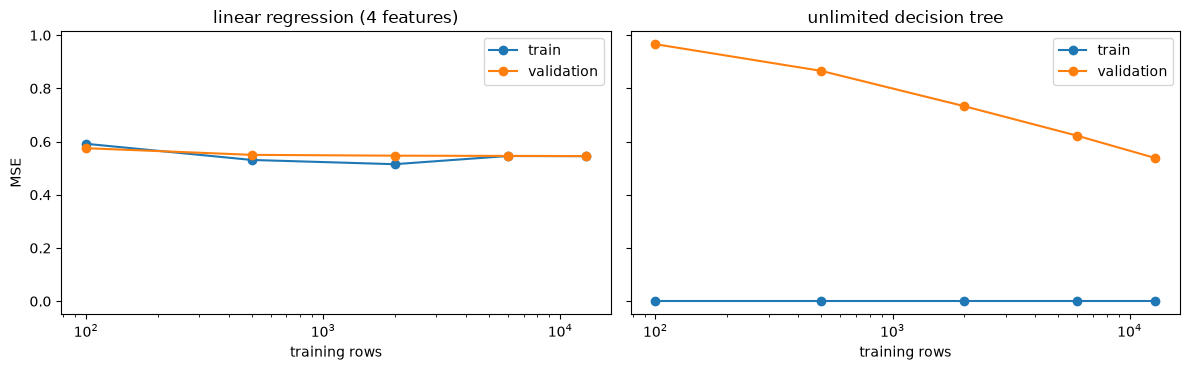

linear regression (4 features)   final train 0.545 | val 0.546 | gap 0.000 → high bias (small gap, errors plateau → richer model)
unlimited decision tree          final train 0.000 | val 0.538 | gap 0.538 → high variance (big gap → more data / regularization)


In [21]:
lc_rows = np.random.default_rng(0).permutation(len(y_house))[:16_000]      # shuffle: the file is sorted by location
X_lc, y_lc = X_house[lc_rows], y_house[lc_rows]
LINEAR_COLS = [housing.feature_names.index(c) for c in ["MedInc", "HouseAge", "Latitude", "Longitude"]]
TRAIN_SIZES = np.array([100, 500, 2000, 6000, 12_800])


def learning_curve_scratch(model, X, y, sizes, n_folds=5):
    """For each fold and size m: fit on the first m rows of the training fold, score MSE on train subset and validation fold."""
    train_mse, val_mse = np.empty((len(sizes), n_folds)), np.empty((len(sizes), n_folds))
    for f, (fold_train, fold_val) in enumerate(KFold(n_folds).split(X)):
        for s, m in enumerate(sizes):
            subset = fold_train[:m]
            fitted = clone(model).fit(X[subset], y[subset])
            train_mse[s, f] = mse(y[subset], fitted.predict(X[subset]))
            val_mse[s, f] = mse(y[fold_val], fitted.predict(X[fold_val]))
    return train_mse, val_mse


curves = {}
for name, model, cols in [("linear regression (4 features)", LinearRegression(), LINEAR_COLS),
                          ("unlimited decision tree", DecisionTreeRegressor(random_state=0), list(range(8)))]:
    ours_train, ours_val = learning_curve_scratch(model, X_lc[:, cols], y_lc, TRAIN_SIZES)
    _, sk_train, sk_val = learning_curve(model, X_lc[:, cols], y_lc, train_sizes=TRAIN_SIZES, cv=KFold(5),
                                         scoring="neg_mean_squared_error")
    assert np.allclose(ours_train, -sk_train) and np.allclose(ours_val, -sk_val)
    curves[name] = (ours_train.mean(axis=1), ours_val.mean(axis=1))
print("✅ from-scratch learning curves equal sklearn.model_selection.learning_curve")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, (name, (tr_curve, va_curve)) in zip(axes, curves.items()):
    ax.plot(TRAIN_SIZES, tr_curve, "o-", label="train")
    ax.plot(TRAIN_SIZES, va_curve, "o-", label="validation")
    ax.set(xscale="log", xlabel="training rows", title=name)
    ax.legend()
axes[0].set_ylabel("MSE")
plt.tight_layout()
plt.show()

for name, (tr_curve, va_curve) in curves.items():
    gap = va_curve[-1] - tr_curve[-1]
    verdict = "high variance (big gap → more data / regularization)" if gap > 0.25 else "high bias (small gap, errors plateau → richer model)"
    print(f"{name:32s} final train {tr_curve[-1]:.3f} | val {va_curve[-1]:.3f} | gap {gap:.3f} → {verdict}")

> 💡 **Interview angle:** "Explain the bias–variance trade-off, and how you'd tell which problem you have." — define both, then say: *compare train vs validation error* (both high → bias; big gap → variance) and *look at a learning curve* to see whether more data would help.

## 8. K-Fold Cross-Validation From Scratch 🟡

A single validation split wastes data and is noisy. **k-fold cross-validation (CV)** splits the training data into k equal **folds**; each fold takes a turn as the validation set while the model trains on the other k−1. The average of the k scores is a more stable estimate, and every row gets used for both training and validation.

```
fold 1: [VAL][ tr][ tr][ tr][ tr]
fold 2: [ tr][VAL][ tr][ tr][ tr]      score = mean of the 5 validation scores
...
fold 5: [ tr][ tr][ tr][ tr][VAL]
```

**Stratified** k-fold keeps the class ratio in every fold. For time series use forward-chaining splits; when several rows come from the same patient/user use **group** k-fold — otherwise the same person leaks across folds.

In [22]:
def kfold_indices(n, k=5, shuffle=False, seed=0):
    """Yield (train_idx, val_idx). The first n % k folds get one extra row (same rule as sklearn.KFold)."""
    order = np.random.default_rng(seed).permutation(n) if shuffle else np.arange(n)
    fold_sizes = np.full(k, n // k)
    fold_sizes[: n % k] += 1
    start = 0
    for size in fold_sizes:
        val = order[start:start + size]
        yield np.concatenate([order[:start], order[start + size:]]), val
        start += size


def stratified_kfold_indices(y, k=5, seed=0):
    """Deal each class's shuffled rows round-robin into k folds, so every fold has ~the same class ratio."""
    gen = np.random.default_rng(seed)
    fold_of = np.empty(len(y), dtype=int)
    for cls in np.unique(y):
        rows = gen.permutation(np.flatnonzero(y == cls))
        fold_of[rows] = np.arange(len(rows)) % k
    for f in range(k):
        yield np.flatnonzero(fold_of != f), np.flatnonzero(fold_of == f)


for (ours_tr, ours_va), (sk_tr, sk_va) in zip(kfold_indices(103, 5), KFold(5).split(np.zeros(103))):
    assert np.array_equal(ours_va, sk_va) and np.array_equal(np.sort(ours_tr), sk_tr)

cv_scores = [Ridge(alpha=1.0).fit(X_diab[a], y_diab[a]).score(X_diab[b], y_diab[b]) for a, b in kfold_indices(len(y_diab), 5)]
assert np.allclose(cv_scores, cross_val_score(Ridge(alpha=1.0), X_diab, y_diab, cv=KFold(5)))
print(f"✅ same folds as KFold and same scores as cross_val_score: R² = {np.mean(cv_scores):.3f} ± {np.std(cv_scores):.3f}")

plain_rates = [y_cancer[b].mean() for _, b in kfold_indices(len(y_cancer), 10, shuffle=True, seed=3)]
strat_rates = [y_cancer[b].mean() for _, b in stratified_kfold_indices(y_cancer, 10, seed=3)]
sk_strat_counts = sorted(int(y_cancer[b].sum()) for _, b in StratifiedKFold(10, shuffle=True, random_state=3).split(X_cancer, y_cancer))
our_strat_counts = sorted(int(y_cancer[b].sum()) for _, b in stratified_kfold_indices(y_cancer, 10, seed=3))
assert max(abs(a - b) for a, b in zip(our_strat_counts, sk_strat_counts)) <= 1
print(f"malignant rate per fold (10 folds) — plain: {min(plain_rates):.2f}–{max(plain_rates):.2f} | stratified: {min(strat_rates):.2f}–{max(strat_rates):.2f}")

✅ same folds as KFold and same scores as cross_val_score: R² = 0.482 ± 0.049
malignant rate per fold (10 folds) — plain: 0.30–0.44 | stratified: 0.37–0.38


### ✍️ Your Turn

Using `kfold_indices` (k = 5, no shuffle), compute `mean_r2`: the average validation R² of `Ridge(alpha=10.0)` on `X_diab, y_diab`. (`model.score` returns R² for regressors.)

In [23]:
mean_r2 = None  # TODO
check("mean_r2", mean_r2, cross_val_score(Ridge(alpha=10.0), X_diab, y_diab, cv=KFold(5)).mean(),
      hint="Loop over kfold_indices(len(y_diab), 5): fit on train rows, score on validation rows, then average.")

⏳ mean_r2: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fold_scores = []
for train_rows, val_rows in kfold_indices(len(y_diab), 5):
    model = Ridge(alpha=10.0).fit(X_diab[train_rows], y_diab[train_rows])
    fold_scores.append(model.score(X_diab[val_rows], y_diab[val_rows]))
mean_r2 = np.mean(fold_scores)
check("mean_r2", mean_r2, cross_val_score(Ridge(alpha=10.0), X_diab, y_diab, cv=KFold(5)).mean())
```
</details>

> 💡 **Interview angle:** "How do you choose k, and when is plain k-fold wrong?" — k = 5 or 10 balances bias and compute; use stratified for classification, `GroupKFold` when rows share an entity (patient, user), and time-ordered splits for forecasting. Everything learned from data (scaling, feature selection, tuning) must happen **inside** each fold.

## 9. Classification Metrics From Scratch 🟡

Start from the **confusion matrix** at a chosen threshold (predict positive when p ≥ threshold):

| | predicted malignant (1) | predicted benign (0) |
|---|---|---|
| **actually malignant (1)** | TP — true positive | FN — false negative (missed cancer) |
| **actually benign (0)** | FP — false positive (false alarm) | TN — true negative |

| Metric | Formula | Question it answers |
|---|---|---|
| Accuracy | (TP+TN) / all | how often are we right? (misleading when classes are imbalanced) |
| **Precision** | TP / (TP+FP) | when we raise an alarm, how often is it real? |
| **Recall** (sensitivity, TPR) | TP / (TP+FN) | of all real cases, how many did we catch? |
| Specificity | TN / (TN+FP) | of all negatives, how many did we correctly clear? |
| FPR | FP / (FP+TN) = 1 − specificity | how often do negatives trigger an alarm? |
| **F1** | 2·P·R / (P+R) | one number balancing precision and recall (harmonic mean) |

**Threshold-free** metrics look at the *ranking* of scores across all thresholds:
- **ROC curve**: TPR vs FPR as the threshold sweeps from high to low; **ROC-AUC** = the probability that a random positive gets a higher score than a random negative.
- **Precision–recall (PR) curve** and **average precision (AP)** = $\sum_n (R_n - R_{n-1}) P_n$, the precision averaged over each gain in recall.

We evaluate the logistic model from section 5 on the cancer **validation** set.

In [24]:
def confusion_counts(y, pred):
    y, pred = np.asarray(y).astype(bool), np.asarray(pred).astype(bool)
    return {"TP": int((pred & y).sum()), "FP": int((pred & ~y).sum()), "FN": int((~pred & y).sum()), "TN": int((~pred & ~y).sum())}


def basic_metrics(counts):
    tp, fp, fn, tn = counts["TP"], counts["FP"], counts["FN"], counts["TN"]
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"accuracy": (tp + tn) / (tp + fp + fn + tn), "precision": precision, "recall": recall, "f1": f1}


pred_va = (p_va_log >= 0.5).astype(int)
cm = confusion_counts(yc_va, pred_va)
ours = basic_metrics(cm)
assert np.array_equal([[cm["TN"], cm["FP"]], [cm["FN"], cm["TP"]]], confusion_matrix(yc_va, pred_va))
assert np.allclose([ours["accuracy"], ours["precision"], ours["recall"], ours["f1"]],
                   [accuracy_score(yc_va, pred_va), precision_score(yc_va, pred_va), recall_score(yc_va, pred_va), f1_score(yc_va, pred_va)])
print("confusion counts:", cm)
print("✅ metrics match sklearn:", {k: round(v, 3) for k, v in ours.items()})

confusion counts: {'TP': 37, 'FP': 1, 'FN': 5, 'TN': 70}
✅ metrics match sklearn: {'accuracy': 0.947, 'precision': 0.974, 'recall': 0.881, 'f1': 0.925}


In [25]:
def roc_curve_scratch(y, scores):
    """FPR, TPR, thresholds — one point per distinct score, highest threshold first (like sklearn with drop_intermediate=False)."""
    order = np.argsort(-scores, kind="mergesort")
    s_sorted, y_sorted = scores[order], y[order]
    last_of_tie = np.r_[np.flatnonzero(np.diff(s_sorted)), len(s_sorted) - 1]   # tied scores are one threshold
    tps = np.cumsum(y_sorted)[last_of_tie]
    fps = (last_of_tie + 1) - tps
    tpr = np.r_[0.0, tps / y.sum()]
    fpr = np.r_[0.0, fps / (len(y) - y.sum())]
    return fpr, tpr, np.r_[np.inf, s_sorted[last_of_tie]], tps, fps


def auc_by_ranks(y, scores):
    """P(score of random positive > score of random negative), ties count ½ — the Mann–Whitney U statistic."""
    ranks = rankdata(scores)                                   # average ranks for ties
    n_pos, n_neg = y.sum(), len(y) - y.sum()
    return (ranks[y == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


fpr, tpr, roc_thr, tps, fps = roc_curve_scratch(yc_va, p_va_log)
sk_fpr, sk_tpr, sk_thr = roc_curve(yc_va, p_va_log, drop_intermediate=False)
assert np.allclose(fpr, sk_fpr) and np.allclose(tpr, sk_tpr) and np.allclose(roc_thr[1:], sk_thr[1:])

auc_trapezoid = np.trapezoid(tpr, fpr)
auc_rank = auc_by_ranks(yc_va, p_va_log)
assert np.isclose(auc_trapezoid, roc_auc_score(yc_va, p_va_log)) and np.isclose(auc_rank, roc_auc_score(yc_va, p_va_log))

pr_precision, pr_recall = tps / (tps + fps), tps / yc_va.sum()
sk_prec, sk_rec, _ = precision_recall_curve(yc_va, p_va_log)          # sklearn: thresholds ascending + a final (P=1, R=0) point
assert np.allclose(pr_precision[::-1], sk_prec[:-1]) and np.allclose(pr_recall[::-1], sk_rec[:-1])
average_precision = np.sum(np.diff(np.r_[0.0, pr_recall]) * pr_precision)
assert np.isclose(average_precision, average_precision_score(yc_va, p_va_log))
print(f"✅ ROC curve, ROC-AUC (trapezoid {auc_trapezoid:.4f} = rank formula {auc_rank:.4f}), PR curve and AP ({average_precision:.4f}) match sklearn")

✅ ROC curve, ROC-AUC (trapezoid 0.9930 = rank formula 0.9930), PR curve and AP (0.9893) match sklearn


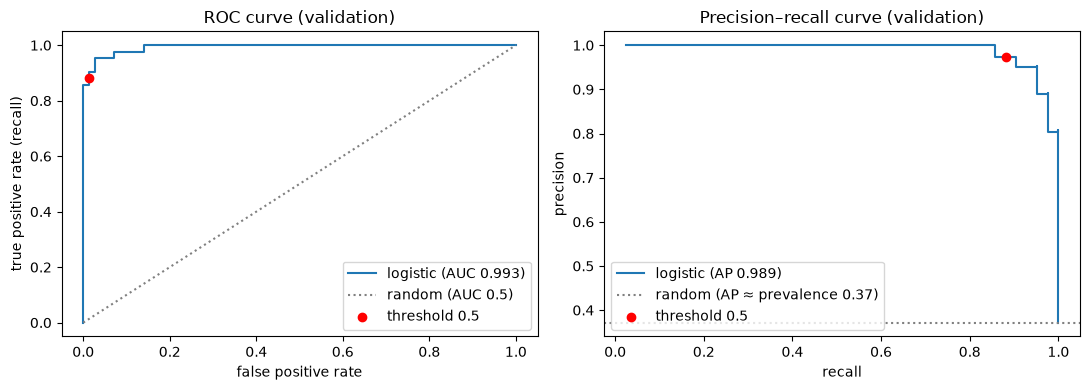

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, drawstyle="steps-post", label=f"logistic (AUC {auc_trapezoid:.3f})")
axes[0].plot([0, 1], [0, 1], ":", c="grey", label="random (AUC 0.5)")
axes[0].scatter([cm["FP"] / (cm["FP"] + cm["TN"])], [ours["recall"]], c="red", zorder=3, label="threshold 0.5")
axes[0].set(xlabel="false positive rate", ylabel="true positive rate (recall)", title="ROC curve (validation)")
axes[1].plot(pr_recall, pr_precision, drawstyle="steps-post", label=f"logistic (AP {average_precision:.3f})")
axes[1].axhline(yc_va.mean(), ls=":", c="grey", label=f"random (AP ≈ prevalence {yc_va.mean():.2f})")
axes[1].scatter([ours["recall"]], [ours["precision"]], c="red", zorder=3, label="threshold 0.5")
axes[1].set(xlabel="recall", ylabel="precision", title="Precision–recall curve (validation)")
for ax in axes:
    ax.legend(loc="lower left" if ax is axes[1] else "lower right")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Compute `specificity` (TN / (TN + FP)) from the confusion counts `cm` of the validation predictions above.

In [27]:
specificity = None  # TODO
check("specificity", specificity, recall_score(1 - yc_va, 1 - pred_va),
      hint="Specificity is recall of the NEGATIVE class: cm['TN'] / (cm['TN'] + cm['FP']).")

⏳ specificity: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
specificity = cm["TN"] / (cm["TN"] + cm["FP"])
check("specificity", specificity, recall_score(1 - yc_va, 1 - pred_va))
```
The checker's trick — recall of the flipped labels — is a handy way to remember what specificity is.
</details>

> 💡 **Interview angle:** "Explain ROC-AUC in one sentence" — the probability that the model scores a randomly chosen positive above a randomly chosen negative. It is threshold-free and insensitive to class balance, which is exactly why it can look great on rare-event problems where precision is terrible (next section).

## 10. Class Imbalance and Threshold Tuning 🟡

Real problems are often **imbalanced**: fraud, disease, defects. We switch to the **mammography** dataset from OpenML — 11,183 real regions from mammograms described by 6 image features, of which only **260 (2.3%) are microcalcifications** — the rare class a radiologist must not miss.

Three tools:
1. **Metrics that respect the rare class** — precision, recall, F1, PR-AUC/AP (not accuracy).
2. **Class weights** — make each minority example count more in the loss (`class_weight="balanced"` weights class c by n / (2·n_c)).
3. **Threshold tuning** — 0.5 is arbitrary; choose the threshold on **validation** data for the metric or cost you care about.

In [28]:
mammo = fetch_openml("mammography", version=1, as_frame=False, parser="auto")
X_mam, y_mam = mammo.data.astype(float), (mammo.target == "1").astype(int)     # OpenML labels are '-1' / '1'
m_tr, m_va, m_te = train_val_test_split(len(y_mam), seed=0, stratify=y_mam)
m_mu, m_sd = X_mam[m_tr].mean(axis=0), X_mam[m_tr].std(axis=0)
Xm_tr, Xm_va, Xm_te = [(X_mam[idx] - m_mu) / m_sd for idx in (m_tr, m_va, m_te)]
ym_tr, ym_va, ym_te = y_mam[m_tr], y_mam[m_va], y_mam[m_te]
print(f"rows {len(y_mam)} | positives {y_mam.sum()} ({y_mam.mean():.2%}) | train/val/test positives: {ym_tr.sum()}/{ym_va.sum()}/{ym_te.sum()}")

always_negative = np.zeros_like(ym_va)
print(f"'always say benign' on validation → accuracy {accuracy_score(ym_va, always_negative):.3f}, recall {recall_score(ym_va, always_negative):.3f}  ← accuracy lies")

rows 11183 | positives 260 (2.32%) | train/val/test positives: 156/52/52
'always say benign' on validation → accuracy 0.977, recall 0.000  ← accuracy lies


In [29]:
M_LAM = 1e-3
class_weight = len(ym_tr) / (2 * np.bincount(ym_tr))                        # "balanced": n / (n_classes · n_c)
w_plain, b_plain, _ = fit_logistic(Xm_tr, ym_tr, lam=M_LAM, max_epochs=50_000)
w_bal, b_bal, _ = fit_logistic(Xm_tr, ym_tr, lam=M_LAM, max_epochs=50_000, sample_weight=class_weight[ym_tr])

C_mam = 1 / (M_LAM * len(ym_tr))
sk_plain = LogisticRegression(C=C_mam, tol=1e-10, max_iter=10_000).fit(Xm_tr, ym_tr)
sk_bal = LogisticRegression(C=C_mam, class_weight="balanced", tol=1e-10, max_iter=10_000).fit(Xm_tr, ym_tr)
assert np.allclose(w_plain, sk_plain.coef_[0], atol=1e-3) and np.allclose(w_bal, sk_bal.coef_[0], atol=1e-3)
print(f"✅ unweighted and class-weighted logistic regression match sklearn (class weights: {class_weight.round(2).tolist()})")

mam_val_proba = {"unweighted": sigmoid(Xm_va @ w_plain + b_plain), "balanced weights": sigmoid(Xm_va @ w_bal + b_bal)}
rows = []
for name, p in mam_val_proba.items():
    rows.append({"model": name, **basic_metrics(confusion_counts(ym_va, p >= 0.5)),
                 "ROC-AUC": roc_auc_score(ym_va, p), "AP (PR-AUC)": average_precision_score(ym_va, p), "mean predicted p": p.mean()})
print("VALIDATION, threshold 0.5")
print(pd.DataFrame(rows).set_index("model").round(3).to_string())

✅ unweighted and class-weighted logistic regression match sklearn (class weights: [0.51, 21.5])
VALIDATION, threshold 0.5
                  accuracy  precision  recall     f1  ROC-AUC  AP (PR-AUC)  mean predicted p
model                                                                                       
unweighted            0.98      0.667   0.308  0.421    0.923        0.563             0.022
balanced weights      0.91      0.185   0.846  0.303    0.918        0.478             0.216


Notice: class weights change **recall and precision at 0.5** dramatically, but ROC-AUC and AP barely move — the *ranking* of cases is nearly the same. Weighting mostly **shifts where 0.5 falls**. So an alternative to weights is to keep the unweighted model and **move the threshold**.

Let's tune the threshold on validation to maximize F1, for both models, all thresholds at once:

In [30]:
THRESHOLDS = np.round(np.arange(0.01, 1.00, 0.01), 2)


def metrics_at_thresholds(y, p, thresholds=THRESHOLDS):
    """Precision, recall, F1 for every threshold at once via a (thresholds × samples) prediction matrix."""
    y = np.asarray(y).astype(bool)
    pred = p[None, :] >= thresholds[:, None]
    tp, fp, fn = (pred & y).sum(1), (pred & ~y).sum(1), (~pred & y).sum(1)
    precision = np.divide(tp, tp + fp, out=np.zeros(len(thresholds)), where=(tp + fp) > 0)
    recall = tp / (tp + fn)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(len(thresholds)), where=(precision + recall) > 0)
    return precision, recall, f1


tuned_thresholds = {}
for name, p in mam_val_proba.items():
    _, _, f1_curve = metrics_at_thresholds(ym_va, p)
    best = int(np.argmax(f1_curve))
    assert np.isclose(f1_curve[best], f1_score(ym_va, p >= THRESHOLDS[best]))
    tuned_thresholds[name] = float(THRESHOLDS[best])
    print(f"{name:17s}: F1 at 0.5 = {f1_curve[np.flatnonzero(THRESHOLDS == 0.5)[0]]:.3f} → best validation F1 {f1_curve[best]:.3f} at threshold {THRESHOLDS[best]:.2f}")

unweighted       : F1 at 0.5 = 0.421 → best validation F1 0.640 at threshold 0.20
balanced weights : F1 at 0.5 = 0.303 → best validation F1 0.606 at threshold 0.89


We will check these validation choices on the **test set once**, together with calibration, at the end of the next section.

> 💡 **Interview angle:** "Your fraud model has 99% accuracy. Is it good?" — compare with the majority-class baseline, then look at precision/recall/PR-AUC for the fraud class; fix imbalance with class weights or resampling **and** a threshold chosen on validation for the business cost.

## 11. Probability Calibration 🔴

A model is **calibrated** if, among all cases where it says "20%", about 20% really are positive. Calibration matters whenever the probability itself is used: expected-cost decisions, risk scores shown to doctors, combining models, ranking ads by expected revenue.

- **Reliability curve**: bin predictions (e.g. 0–0.1, 0.1–0.2, …); in each bin plot mean predicted probability (x) vs actual fraction of positives (y). Perfect calibration = the diagonal.
- **Brier score**: mean of $(p - y)^2$ — lower is better; it rewards both good ranking and honest probabilities.
- **Fixes** (fit on held-out data, never on training data): **Platt scaling** (a 1-D logistic regression on the model's logits) or **isotonic regression** (a monotone step function; needs more data).

Class weighting from the previous section *deliberately* distorts probabilities: the balanced model pretends positives are 50% of the data.

In [31]:
def reliability_curve(y, p, n_bins=10):
    """Fraction of positives and mean predicted probability per non-empty uniform bin (same binning as sklearn)."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_id = np.searchsorted(edges[1:-1], p)
    counts = np.bincount(bin_id, minlength=n_bins)
    frac_pos = np.bincount(bin_id, weights=y, minlength=n_bins)
    mean_pred = np.bincount(bin_id, weights=p, minlength=n_bins)
    keep = counts > 0
    return frac_pos[keep] / counts[keep], mean_pred[keep] / counts[keep], counts[keep]


for name, p in mam_val_proba.items():
    frac, mean_p, counts = reliability_curve(ym_va, p)
    sk_frac, sk_mean = calibration_curve(ym_va, p, n_bins=10)
    assert np.allclose(frac, sk_frac) and np.allclose(mean_p, sk_mean)
    brier = np.mean((p - ym_va) ** 2)
    assert np.isclose(brier, brier_score_loss(ym_va, p))
    print(f"{name:17s}: Brier {brier:.4f} | mean predicted {p.mean():.3f} vs actual positive rate {ym_va.mean():.3f}")
print("✅ reliability curve and Brier score match sklearn")

unweighted       : Brier 0.0143 | mean predicted 0.022 vs actual positive rate 0.023
balanced weights : Brier 0.0790 | mean predicted 0.216 vs actual positive rate 0.023
✅ reliability curve and Brier score match sklearn


**Platt scaling from scratch.** Fit $p_{cal} = \sigma(a \cdot z + b)$ on **validation** logits $z$. Scikit-learn (following Platt, 1999) uses slightly smoothed targets — $\frac{N_+ + 1}{N_+ + 2}$ for positives and $\frac{1}{N_- + 2}$ for negatives — to avoid overconfidence; we do the same and compare with `CalibratedClassifierCV(FrozenEstimator(model), method="sigmoid")`.

In [32]:
def platt_fit(logits, y):
    n_pos, n_neg = y.sum(), len(y) - y.sum()
    target = np.where(y == 1, (n_pos + 1) / (n_pos + 2), 1 / (n_neg + 2))

    def loss_and_grad(ab):
        z = ab[0] * logits + ab[1]
        loss = np.sum(np.logaddexp(0, z) - target * z)
        g = sigmoid(z) - target
        return loss, np.array([g @ logits, g.sum()])

    return minimize(loss_and_grad, x0=np.array([1.0, 0.0]), jac=True, method="L-BFGS-B", options={"gtol": 1e-10}).x


a_platt, b_platt = platt_fit(Xm_va @ w_bal + b_bal, ym_va)
sk_calibrated = CalibratedClassifierCV(FrozenEstimator(sk_bal), method="sigmoid").fit(Xm_va, ym_va)   # frozen = don't refit the model
p_te_bal = sigmoid(Xm_te @ w_bal + b_bal)
p_te_platt = sigmoid(a_platt * (Xm_te @ w_bal + b_bal) + b_platt)
assert np.allclose(p_te_platt, sk_calibrated.predict_proba(Xm_te)[:, 1], atol=1e-4)
print(f"✅ Platt scaling matches CalibratedClassifierCV (a = {a_platt:.3f}, b = {b_platt:.3f})")

✅ Platt scaling matches CalibratedClassifierCV (a = 0.892, b = -3.490)


### 🔒 Mammography: the one look at the test set

All choices above (class weights, thresholds, calibration map) were made on training/validation data. Now we evaluate them **once** on test.

TEST set: 2237 rows, positive rate 0.023
                  F1 @0.5      AP   Brier  mean p  val-tuned threshold  F1 @tuned
model                                                                            
unweighted         0.4658  0.5703  0.0145  0.0203                 0.20     0.5591
balanced weights   0.2983  0.5435  0.0794  0.2167                 0.89     0.5306
balanced + Platt   0.3636  0.5435  0.0153  0.0204                  NaN        NaN


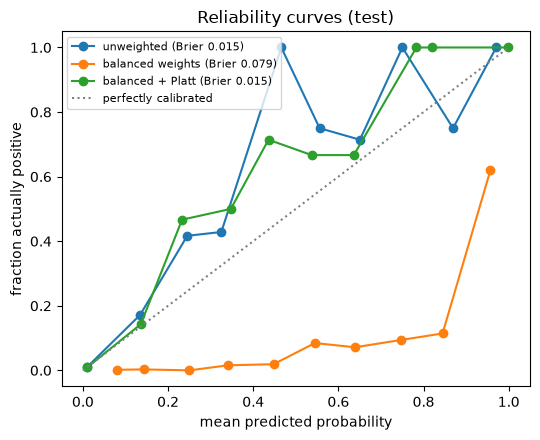

In [33]:
p_te_plain = sigmoid(Xm_te @ w_plain + b_plain)
final_rows = []
for name, p, t in [("unweighted", p_te_plain, tuned_thresholds["unweighted"]),
                   ("balanced weights", p_te_bal, tuned_thresholds["balanced weights"]),
                   ("balanced + Platt", p_te_platt, None)]:
    row = {"model": name, "F1 @0.5": f1_score(ym_te, p >= 0.5, zero_division=0), "AP": average_precision_score(ym_te, p),
           "Brier": brier_score_loss(ym_te, p), "mean p": p.mean()}
    row["val-tuned threshold"], row["F1 @tuned"] = (t, f1_score(ym_te, p >= t)) if t is not None else (np.nan, np.nan)
    final_rows.append(row)
final_mam = pd.DataFrame(final_rows).set_index("model")
print(f"TEST set: {len(ym_te)} rows, positive rate {ym_te.mean():.3f}")
print(final_mam.round(4).to_string())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for name, p in [("unweighted", p_te_plain), ("balanced weights", p_te_bal), ("balanced + Platt", p_te_platt)]:
    frac, mean_p, _ = reliability_curve(ym_te, p)
    ax.plot(mean_p, frac, "o-", label=f"{name} (Brier {brier_score_loss(ym_te, p):.3f})")
ax.plot([0, 1], [0, 1], ":", c="grey", label="perfectly calibrated")
ax.set(xlabel="mean predicted probability", ylabel="fraction actually positive", title="Reliability curves (test)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

> 💡 **Interview angle:** "What is calibration and how do you fix it?" — predicted probabilities match observed frequencies. Check with a reliability diagram and Brier score / log loss; fix with Platt (sigmoid) or isotonic regression fitted on held-out data. Class weights, resampling, boosting, and deep nets often break calibration while leaving AUC unchanged.

## 12. Decision Trees: Gini, Entropy, Information Gain 🟡

A decision tree asks yes/no questions ("is worst area ≤ 884?") and follows branches to a leaf that predicts the majority class. It picks each question greedily: the split that makes the child nodes **purest**.

**Impurity** of a node with class proportions $p_k$:
- **Gini** $= 1 - \sum_k p_k^2$ — the chance two random picks from the node disagree. 0 = pure; 0.5 = 50/50 (two classes).
- **Entropy** $= -\sum_k p_k \log_2 p_k$ — bits of uncertainty. 0 = pure; 1 = 50/50.

**Information gain** of a split = parent impurity − weighted average child impurity. The tree tries every feature and every threshold (midpoints between sorted values) and keeps the largest gain.

In [34]:
def impurity(counts, criterion="gini"):
    counts = np.asarray(counts, dtype=float)
    p = counts / counts.sum(axis=-1, keepdims=True)
    if criterion == "gini":
        return 1.0 - (p ** 2).sum(axis=-1)
    with np.errstate(divide="ignore", invalid="ignore"):
        logs = np.where(p > 0, np.log2(p), 0.0)
    return 0.0 - (p * logs).sum(axis=-1)          # 0.0 - x avoids printing -0.0 for pure nodes


print("Gini    [50,50], [90,10], [100,0]:", impurity([[50, 50], [90, 10], [100, 0]]).round(3))
print("Entropy [50,50], [90,10], [100,0]:", impurity([[50, 50], [90, 10], [100, 0]], "entropy").round(3))


def best_split(X, y, criterion="gini", n_classes=2):
    """Try every feature and midpoint threshold; return (feature, threshold, weighted child impurity)."""
    n, d = X.shape
    parent_counts = np.bincount(y, minlength=n_classes)
    best = (None, None, np.inf)
    for j in range(d):
        order = np.argsort(X[:, j], kind="mergesort")
        xs, ys = X[order, j], y[order]
        left_counts = np.cumsum(np.eye(n_classes)[ys], axis=0)[:-1]       # class counts left of each cut
        right_counts = parent_counts - left_counts
        n_left = np.arange(1, n)
        child_impurity = (n_left * impurity(left_counts, criterion) + (n - n_left) * impurity(right_counts, criterion)) / n
        child_impurity[xs[1:] == xs[:-1]] = np.inf                        # can't cut between equal values
        k = int(np.argmin(child_impurity))
        if child_impurity[k] < best[2]:
            best = (j, (xs[k] + xs[k + 1]) / 2, child_impurity[k])
    return best


def build_tree(X, y, rows=None, depth=0, max_depth=3, criterion="gini", n_classes=2):
    rows = np.arange(len(y)) if rows is None else rows
    counts = np.bincount(y[rows], minlength=n_classes)
    node = {"counts": counts, "rows": rows}
    if depth == max_depth or counts.max() == len(rows):                  # depth limit or pure node → leaf
        return node
    feature, threshold, child_imp = best_split(X[rows], y[rows], criterion, n_classes)
    if feature is None:
        return node
    go_left = X[rows, feature] <= threshold
    node.update(feature=feature, threshold=threshold, gain=impurity(counts, criterion) - child_imp,
                left=build_tree(X, y, rows[go_left], depth + 1, max_depth, criterion, n_classes),
                right=build_tree(X, y, rows[~go_left], depth + 1, max_depth, criterion, n_classes))
    return node


def predict_tree(node, X):
    out = np.empty(len(X), dtype=int)
    for i, x in enumerate(X):
        current = node
        while "feature" in current:
            current = current["left"] if x[current["feature"]] <= current["threshold"] else current["right"]
        out[i] = current["counts"].argmax()
    return out

Gini    [50,50], [90,10], [100,0]: [0.5  0.18 0.  ]
Entropy [50,50], [90,10], [100,0]: [1.    0.469 0.   ]


In [35]:
tree_ours = build_tree(X_cancer, y_cancer, rows=tr_idx, max_depth=3)
tree_sk = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_cancer[tr_idx], yc_tr).tree_

root = tree_ours
print(f"root split: '{cancer.feature_names[root['feature']]}' <= {root['threshold']:.3f} | information gain {root['gain']:.4f}")


def preorder(node, out):
    out.append(node)
    if "feature" in node:
        preorder(node["left"], out)
        preorder(node["right"], out)
    return out


ties = 0
for i, node in enumerate(preorder(tree_ours, [])):
    sk_counts = np.round(tree_sk.value[i][0] * tree_sk.n_node_samples[i]).astype(int)
    assert np.array_equal(node["counts"], sk_counts), f"node {i}: class counts differ"
    if "feature" in node and node["feature"] != tree_sk.feature[i]:
        # Different feature: it must be an exact tie (sklearn breaks ties by a random feature order)
        rows, f_sk, t_sk = node["rows"], tree_sk.feature[i], tree_sk.threshold[i]
        left = X_cancer[rows, f_sk] <= t_sk
        sk_child = (left.sum() * impurity(np.bincount(y_cancer[rows][left], minlength=2))
                    + (~left).sum() * impurity(np.bincount(y_cancer[rows][~left], minlength=2))) / len(rows)
        assert np.isclose(impurity(node["counts"]) - node["gain"], sk_child)
        ties += 1
    elif "feature" in node:
        assert np.isclose(node["threshold"], tree_sk.threshold[i], atol=1e-4)   # sklearn stores float32 thresholds
print(f"✅ every node has the same class counts as sklearn; {ties} split(s) differ only by an exact impurity tie")

agree = np.mean(predict_tree(tree_ours, X_cancer[va_idx]) == DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_cancer[tr_idx], yc_tr).predict(X_cancer[va_idx]))
print(f"validation accuracy (ours) {np.mean(predict_tree(tree_ours, X_cancer[va_idx]) == yc_va):.3f} | predictions agree with sklearn on {agree:.1%}")

root split: 'worst perimeter' <= 114.450 | information gain 0.3505
✅ every node has the same class counts as sklearn; 1 split(s) differ only by an exact impurity tie
validation accuracy (ours) 0.894 | predictions agree with sklearn on 99.1%


### ✍️ Your Turn

Compute `entropy_82`: the entropy (in bits) of a node with class counts `[8, 2]`, using NumPy only.

In [36]:
entropy_82 = None  # TODO
check("entropy_82", entropy_82, 0.7219280948873623, hint="-(0.8·log2(0.8) + 0.2·log2(0.2))")

⏳ entropy_82: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p = np.array([8, 2]) / 10
entropy_82 = -np.sum(p * np.log2(p))
check("entropy_82", entropy_82, 0.7219280948873623)
```
The Gini impurity of the same node is 1 − (0.64 + 0.04) = 0.32. Both are 0 for a pure node and largest at 50/50.
</details>

> 💡 **Interview angle:** "Gini or entropy?" — they almost always choose the same splits; Gini is slightly cheaper (no logarithm) and is scikit-learn's default, entropy has an information-theory reading. The bigger decisions are depth, `min_samples_leaf`, and pruning, because a fully grown tree overfits.

## 13. Feature Scaling Effects 🟢

**Standardizing** ($z = (x - \mu) / \sigma$, with μ and σ from the training data) matters for models that use **distances** or **gradients**, and not for trees:

| Model family | Scaling needed? | Why |
|---|---|---|
| Gradient descent (linear/logistic regression, neural nets) | ✅ yes | one learning rate must suit every feature's scale |
| k-NN, k-means, SVM with RBF kernel, PCA | ✅ yes | distances are dominated by large-unit features |
| L1/L2-regularized models | ✅ yes | the penalty would punish features for their units |
| Decision trees, random forests, gradient boosting | ❌ no | splits only depend on the order of values |

In [37]:
raw_tr = X_cancer[tr_idx]
print("cancer feature scales (train std): smallest", raw_tr.std(axis=0).min().round(4), "| largest", raw_tr.std(axis=0).max().round(1))
for label, X_fit, lr in [("raw features, lr=0.1", raw_tr, 0.1), ("raw features, lr=1e-5", raw_tr, 1e-5), ("standardized, lr=0.5", Xc_tr, 0.5)]:
    w_s, b_s, hist = fit_logistic(X_fit, yc_tr, lr=lr, max_epochs=3000, tol=1e-6)
    print(f"{label:22s} → training log loss after {len(hist)} epochs: {hist[-1]:.4f}")

wine = load_wine()
w_tr, w_va, _ = train_val_test_split(len(wine.target), seed=0, stratify=wine.target)
wine_mu, wine_sd = wine.data[w_tr].mean(axis=0), wine.data[w_tr].std(axis=0)
knn_raw = KNeighborsClassifier(5).fit(wine.data[w_tr], wine.target[w_tr]).score(wine.data[w_va], wine.target[w_va])
knn_scaled = KNeighborsClassifier(5).fit((wine.data[w_tr] - wine_mu) / wine_sd, wine.target[w_tr]).score((wine.data[w_va] - wine_mu) / wine_sd, wine.target[w_va])
print(f"\nwine k-NN validation accuracy: raw {knn_raw:.3f} vs standardized {knn_scaled:.3f}  (proline ranges up to {wine.data[:, 12].max():.0f}, hue below {wine.data[:, 10].max():.1f})")

tree_raw = DecisionTreeClassifier(random_state=0).fit(wine.data[w_tr], wine.target[w_tr]).predict(wine.data[w_va])
tree_scaled = DecisionTreeClassifier(random_state=0).fit((wine.data[w_tr] - wine_mu) / wine_sd, wine.target[w_tr]).predict((wine.data[w_va] - wine_mu) / wine_sd)
assert np.array_equal(tree_raw, tree_scaled)
print("✅ decision tree predictions are identical with and without scaling")

cancer feature scales (train std): smallest 0.0027 | largest 587.3
raw features, lr=0.1   → training log loss after 3000 epochs: 264.7770


raw features, lr=1e-5  → training log loss after 3000 epochs: 0.2025


standardized, lr=0.5   → training log loss after 3000 epochs: 0.0254



wine k-NN validation accuracy: raw 0.694 vs standardized 0.944  (proline ranges up to 1680, hue below 1.7)
✅ decision tree predictions are identical with and without scaling


> 💡 **Interview angle:** "Do you need to scale features for a random forest? For k-NN?" — no for tree ensembles (order-based splits), yes for k-NN/SVM/linear models/neural nets. And always fit the scaler on training data only — inside each CV fold.

## 14. Data Leakage 🔴

**Data leakage** = information that would not be available at prediction time sneaks into training or model selection, so validation scores look better than real life.

| Leak type | Example |
|---|---|
| Target leakage | predicting churn with "account closed date", or disease with a drug only prescribed after diagnosis |
| Train–test contamination | scaling, imputing, or **selecting features on all data** before splitting; duplicate rows across splits |
| Group leakage | the same patient's scans in train and test → the model recognizes the patient |
| Temporal leakage | random splits on time series → training on the future |

**A concrete experiment.** We keep the real 569 cancer labels but replace the features with **5,000 columns of pure random noise** (on purpose — no real signal exists). Then we select the 20 columns most correlated with the label and cross-validate a logistic regression:
- ❌ **leaky**: select features using *all* rows, then cross-validate;
- ✅ **correct**: select features *inside* each training fold.

In [38]:
noise = np.random.default_rng(7).normal(size=(len(y_cancer), 5000))


def top_k_by_correlation(X, y, k=20):
    Xc_ = X - X.mean(axis=0)
    yc_ = y - y.mean()
    corr = (Xc_.T @ yc_) / (np.sqrt((Xc_ ** 2).sum(axis=0)) * np.sqrt((yc_ ** 2).sum()))
    return np.argsort(-np.abs(corr))[:k]


def cv_auc_with_selection(X, y, select_inside_folds, k=20):
    leaky_columns = top_k_by_correlation(X, y, k)                     # uses validation rows' labels!
    aucs = []
    for fold_train, fold_val in stratified_kfold_indices(y, 5, seed=0):
        cols = top_k_by_correlation(X[fold_train], y[fold_train], k) if select_inside_folds else leaky_columns
        model = LogisticRegression(max_iter=2000).fit(X[fold_train][:, cols], y[fold_train])
        aucs.append(roc_auc_score(y[fold_val], model.predict_proba(X[fold_val][:, cols])[:, 1]))
    return float(np.mean(aucs))


leaky_auc = cv_auc_with_selection(noise, y_cancer, select_inside_folds=False)
honest_auc = cv_auc_with_selection(noise, y_cancer, select_inside_folds=True)
print(f"❌ leaky CV ROC-AUC on pure noise : {leaky_auc:.3f}")
print(f"✅ correct CV ROC-AUC on pure noise: {honest_auc:.3f}  (0.5 = no signal, the truth)")

❌ leaky CV ROC-AUC on pure noise : 0.763
✅ correct CV ROC-AUC on pure noise: 0.502  (0.5 = no signal, the truth)


The scikit-learn way to make this impossible to get wrong is a **Pipeline**: every step is re-fitted inside each fold. `SelectKBest(f_classif)` ranks by the same statistic as our correlation (for two classes the F-statistic is a monotone function of |correlation|).

In [39]:
from sklearn.feature_selection import SelectKBest, f_classif

assert set(SelectKBest(f_classif, k=20).fit(noise, y_cancer).get_support(indices=True)) == set(top_k_by_correlation(noise, y_cancer, 20))
pipeline = make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=2000))
pipe_auc = cross_val_score(pipeline, noise, y_cancer, cv=StratifiedKFold(5, shuffle=True, random_state=0), scoring="roc_auc").mean()
print(f"✅ Pipeline(SelectKBest → LogisticRegression) CV ROC-AUC: {pipe_auc:.3f}")

✅ Pipeline(SelectKBest → LogisticRegression) CV ROC-AUC: 0.494


> 💡 **Interview angle:** "Your validation AUC is 0.97 but production is 0.70 — what do you check?" — leakage first (features unavailable at prediction time, preprocessing/feature selection outside CV, duplicates or the same user/patient across splits, random splits on time data), then distribution shift between training and production.

## 🔧 Build It From Scratch

### A mini scikit-learn: our logistic regression inside a cross-validated grid search

Interviewers love *"implement it, then show it's correct"*. We wrap our gradient-descent logistic regression in the scikit-learn estimator API (`fit`, `predict_proba`, `get_params` via `BaseEstimator`), then write our **own** grid search with **in-fold scaling** and compare it with `GridSearchCV(Pipeline(StandardScaler, LogisticRegression))` on identical folds.

In [40]:
class ScratchLogisticRegression(ClassifierMixin, BaseEstimator):
    """L2 logistic regression trained with our fit_logistic. Parameterized by C like sklearn (λ = 1 / (C · n))."""

    def __init__(self, C=1.0, class_weight=None):
        self.C = C
        self.class_weight = class_weight

    def fit(self, X, y):
        X, y = np.asarray(X, dtype=float), np.asarray(y).astype(int)
        self.classes_ = np.array([0, 1])
        weights = None
        if self.class_weight == "balanced":
            weights = (len(y) / (2 * np.bincount(y, minlength=2)))[y]
        self.coef_, self.intercept_, _ = fit_logistic(X, y, lam=1.0 / (self.C * len(y)), max_epochs=50_000, tol=1e-7,
                                                      sample_weight=weights)
        return self

    def predict_proba(self, X):
        p = sigmoid(np.asarray(X, dtype=float) @ self.coef_ + self.intercept_)
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def grid_search_cv_scratch(model, X, y, C_grid, folds):
    """Mean validation log loss per C. The scaler is fitted inside each training fold (no leakage)."""
    results = {}
    for C in C_grid:
        fold_losses = []
        for fold_train, fold_val in folds:
            mu, sd = X[fold_train].mean(axis=0), X[fold_train].std(axis=0)
            fitted = clone(model).set_params(C=C).fit((X[fold_train] - mu) / sd, y[fold_train])
            fold_losses.append(binary_log_loss(y[fold_val], fitted.predict_proba((X[fold_val] - mu) / sd)[:, 1]))
        results[C] = (float(np.mean(fold_losses)), float(np.std(fold_losses)))
    return results


C_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]
cancer_folds = list(stratified_kfold_indices(yc_tr, 5, seed=0))
X_cancer_tr_raw = X_cancer[tr_idx]

start = time.perf_counter()
ours_cv = grid_search_cv_scratch(ScratchLogisticRegression(), X_cancer_tr_raw, yc_tr, C_GRID, cancer_folds)
ours_seconds = time.perf_counter() - start

sk_search = GridSearchCV(make_pipeline(StandardScaler(), LogisticRegression(tol=1e-10, max_iter=10_000)),
                         {"logisticregression__C": C_GRID}, cv=cancer_folds, scoring="neg_log_loss").fit(X_cancer_tr_raw, yc_tr)
sk_losses = -sk_search.cv_results_["mean_test_score"]
assert np.allclose([ours_cv[C][0] for C in C_GRID], sk_losses, atol=1e-3)
best_C = min(ours_cv, key=lambda C: ours_cv[C][0])
assert best_C == sk_search.best_params_["logisticregression__C"]

# Our estimator also plugs straight into scikit-learn's own tools
plugged = cross_val_score(make_pipeline(StandardScaler(), ScratchLogisticRegression(C=best_C)), X_cancer_tr_raw, yc_tr,
                          cv=cancer_folds, scoring="neg_log_loss")
assert np.isclose(-plugged.mean(), ours_cv[best_C][0], atol=1e-6)

print(pd.DataFrame({"ours: mean CV log loss": [ours_cv[C][0] for C in C_GRID], "sklearn GridSearchCV": sk_losses},
                   index=pd.Index(C_GRID, name="C")).round(4).to_string())
print(f"✅ same CV losses and same best C = {best_C} as GridSearchCV (our search took {ours_seconds:.1f}s);"
      " our estimator also works inside sklearn's Pipeline + cross_val_score")

      ours: mean CV log loss  sklearn GridSearchCV
C                                                 
0.01                  0.2032                0.2032
0.03                  0.1407                0.1407
0.10                  0.0978                0.0978
0.30                  0.0764                0.0764
1.00                  0.0693                0.0693
3.00                  0.0790                0.0790
✅ same CV losses and same best C = 1.0 as GridSearchCV (our search took 1.9s); our estimator also works inside sklearn's Pipeline + cross_val_score


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Using scikit-learn's breast-cancer target as "1 = malignant"

`load_breast_cancer().target` is **0 = malignant, 1 = benign**. Train on it directly and `recall_score` silently reports the recall of **benign** tumours.

In [41]:
raw_target = cancer.target                                            # 0 = malignant, 1 = benign
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_cancer[tr_idx], raw_target[tr_idx])
raw_pred = clf.predict(X_cancer[va_idx])
print(f"❌ recall_score(raw target) = {recall_score(raw_target[va_idx], raw_pred):.3f}  ← this is BENIGN recall")
print(f"✅ malignant recall (pos_label=0) = {recall_score(raw_target[va_idx], raw_pred, pos_label=0):.3f}"
      f" | same as with flipped labels: {recall_score(1 - raw_target[va_idx], 1 - raw_pred):.3f}")

❌ recall_score(raw target) = 0.972  ← this is BENIGN recall
✅ malignant recall (pos_label=0) = 0.905 | same as with flipped labels: 0.905


### ❌ Pitfall 2 — Computing ROC-AUC from hard 0/1 predictions

AUC measures ranking. Hard labels have only two "scores", so the curve collapses to a single point and the AUC drops.

In [42]:
print(f"❌ roc_auc_score(y, predict())       = {roc_auc_score(yc_va, pred_va):.3f}")
print(f"✅ roc_auc_score(y, predict_proba()) = {roc_auc_score(yc_va, p_va_log):.3f}")

❌ roc_auc_score(y, predict())       = 0.933
✅ roc_auc_score(y, predict_proba()) = 0.993


### ❌ Pitfall 3 — Regularizing features on different scales

Change the units of `bmi` (e.g. divide by 100) and lasso removes the dataset's most important feature — just because a unit change means its weight must be 100× larger to have the same effect, and the penalty grows with the weight.

In [43]:
bmi = DIAB_FEATURES.index("bmi")
X_units = X_diab.copy()
X_units[:, bmi] /= 100                                                 # same information, different units
wrong_w, _ = lasso_coordinate_descent(X_units, y_diab, alpha=5.0)
right_w, _ = lasso_coordinate_descent((X_units - X_units.mean(axis=0)) / X_units.std(axis=0), y_diab, alpha=5.0)
print("❌ unscaled: lasso keeps", [DIAB_FEATURES[j] for j in np.flatnonzero(wrong_w)], "| bmi weight:", round(float(wrong_w[bmi]), 2))
print("✅ standardized: lasso keeps", [DIAB_FEATURES[j] for j in np.flatnonzero(right_w)], "| bmi weight:", round(float(right_w[bmi]), 2))

❌ unscaled: lasso keeps ['sex', 'bp', 's3', 's5', 's6'] | bmi weight: 0.0
✅ standardized: lasso keeps ['sex', 'bmi', 'bp', 's3', 's5'] | bmi weight: 24.22


### ❌ Pitfall 4 — Random (unstratified) splits on rare classes

With 2.3% positives, a random 20% validation split can have very different numbers of positives from one seed to the next, making metrics jumpy.

In [44]:
unstratified = [int(y_mam[train_val_test_split(len(y_mam), seed=s)[1]].sum()) for s in range(8)]
stratified = [int(y_mam[train_val_test_split(len(y_mam), seed=s, stratify=y_mam)[1]].sum()) for s in range(8)]
print("❌ positives in validation, 8 random seeds  :", unstratified)
print("✅ positives in validation, 8 stratified seeds:", stratified)

❌ positives in validation, 8 random seeds  : [49, 49, 55, 40, 58, 47, 46, 56]
✅ positives in validation, 8 stratified seeds: [52, 52, 52, 52, 52, 52, 52, 52]


### ❌ Pitfall 5 — Taking log(0) in log loss

One prediction of exactly 0 for a true positive makes the average log loss infinite (and gradients undefined).

In [45]:
y_p5, p_p5 = np.array([1, 0, 1]), np.array([0.0, 0.1, 0.9])
with np.errstate(divide="ignore", invalid="ignore"):
    naive = -np.mean(y_p5 * np.log(p_p5) + (1 - y_p5) * np.log(1 - p_p5))
print(f"❌ naive log loss: {naive}")
print(f"✅ clipped log loss: {binary_log_loss(y_p5, p_p5):.3f} (sklearn clips too: {log_loss(y_p5, p_p5):.3f}); better still, compute from logits with logaddexp")

❌ naive log loss: inf
✅ clipped log loss: 11.583 (sklearn clips too: 12.085); better still, compute from logits with logaddexp


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Metrics from a confusion matrix
A spam filter has TP = 40, FP = 10, FN = 5, TN = 45. Compute `[accuracy, precision, recall, f1]` as a list.

In [46]:
ex1_metrics = None  # TODO
check("ex1_metrics", ex1_metrics, [0.85, 0.8, 40 / 45, 2 * 0.8 * (40 / 45) / (0.8 + 40 / 45)],
      hint="precision = TP/(TP+FP), recall = TP/(TP+FN), F1 = 2PR/(P+R)")

⏳ ex1_metrics: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tp, fp, fn, tn = 40, 10, 5, 45
precision, recall = tp / (tp + fp), tp / (tp + fn)
ex1_metrics = [(tp + tn) / (tp + fp + fn + tn), precision, recall, 2 * precision * recall / (precision + recall)]
check("ex1_metrics", ex1_metrics, [0.85, 0.8, 40 / 45, 2 * 0.8 * (40 / 45) / (0.8 + 40 / 45)])
```
</details>

### 🟢 Exercise 2 — MSE and MAE by hand
For `y = [2, 4, 6]` and `ŷ = [3, 4, 8]`, compute `[mse_value, mae_value]` with NumPy.

In [47]:
y_ex2, yhat_ex2 = np.array([2.0, 4.0, 6.0]), np.array([3.0, 4.0, 8.0])
ex2_losses = None  # TODO
check("ex2_losses", ex2_losses, [5 / 3, 1.0], hint="np.mean((y - ŷ)**2) and np.mean(np.abs(y - ŷ))")

⏳ ex2_losses: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_ex2, yhat_ex2 = np.array([2.0, 4.0, 6.0]), np.array([3.0, 4.0, 8.0])
ex2_losses = [np.mean((y_ex2 - yhat_ex2) ** 2), np.mean(np.abs(y_ex2 - yhat_ex2))]
check("ex2_losses", ex2_losses, [5 / 3, 1.0])
```
The error of 2 contributes 4 to the squared sum but only 2 to the absolute sum — MSE weighs big misses more.
</details>

### 🟢 Exercise 3 — Gini and entropy
A node has 30 benign and 10 malignant tumours. Compute `[gini, entropy_bits]`.

In [48]:
ex3_impurities = None  # TODO
check("ex3_impurities", ex3_impurities, [0.375, 0.8112781244591328], hint="p = [0.75, 0.25]; gini = 1 − Σp²; entropy = −Σ p·log2 p")

⏳ ex3_impurities: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p = np.array([30, 10]) / 40
ex3_impurities = [1 - np.sum(p ** 2), -np.sum(p * np.log2(p))]
check("ex3_impurities", ex3_impurities, [0.375, 0.8112781244591328])
```
</details>

### 🟡 Exercise 4 — ROC-AUC without scikit-learn (with ties)
Implement `auc_pairs(y, s)`: the fraction of (positive, negative) pairs where the positive has the higher score, counting ties as ½. Use broadcasting, not loops.

In [49]:
y_ex4 = np.array([1, 0, 1, 0, 1, 0])
s_ex4 = np.array([0.9, 0.4, 0.4, 0.2, 0.7, 0.8])


def auc_pairs(y, s):
    return None  # TODO


check("ex4_auc", auc_pairs(y_ex4, s_ex4), roc_auc_score(y_ex4, s_ex4),
      hint="diff = s[y==1][:, None] - s[y==0][None, :]; mean of (diff > 0) + 0.5 * (diff == 0)")

⏳ ex4_auc: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_ex4 = np.array([1, 0, 1, 0, 1, 0])
s_ex4 = np.array([0.9, 0.4, 0.4, 0.2, 0.7, 0.8])

def auc_pairs(y, s):
    diff = s[y == 1][:, None] - s[y == 0][None, :]        # (n_pos, n_neg) matrix of score differences
    return np.mean((diff > 0) + 0.5 * (diff == 0))

check("ex4_auc", auc_pairs(y_ex4, s_ex4), roc_auc_score(y_ex4, s_ex4))
```
O(n_pos · n_neg) memory — fine here; for millions of rows use the rank formula (`auc_by_ranks`), which is O(n log n).
</details>

### 🟡 Exercise 5 — Ridge with an unpenalized intercept
Fit ridge regression with `alpha = 2.0` on `X_ex5, y_ex5` using the closed form (center X and y first, don't penalize the intercept). Store `[w0, w1, intercept]`.

In [50]:
X_ex5 = np.array([[1.0, 2.0], [2.0, 0.0], [3.0, 1.0], [4.0, 3.0], [5.0, 5.0]])
y_ex5 = np.array([3.0, 3.5, 5.0, 8.0, 10.5])
ex5_params = None  # TODO
sk_ex5 = Ridge(alpha=2.0).fit(X_ex5, y_ex5)
check("ex5_ridge", ex5_params, [*sk_ex5.coef_, sk_ex5.intercept_], hint="w = solve(XcᵀXc + αI, Xcᵀyc); b = ȳ − x̄·w")

⏳ ex5_ridge: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_ex5 = np.array([[1.0, 2.0], [2.0, 0.0], [3.0, 1.0], [4.0, 3.0], [5.0, 5.0]])
y_ex5 = np.array([3.0, 3.5, 5.0, 8.0, 10.5])
x_bar, y_bar = X_ex5.mean(axis=0), y_ex5.mean()
Xc_, yc_ = X_ex5 - x_bar, y_ex5 - y_bar
w = np.linalg.solve(Xc_.T @ Xc_ + 2.0 * np.eye(2), Xc_.T @ yc_)
ex5_params = [*w, y_bar - x_bar @ w]
sk_ex5 = Ridge(alpha=2.0).fit(X_ex5, y_ex5)
check("ex5_ridge", ex5_params, [*sk_ex5.coef_, sk_ex5.intercept_])
```
</details>

### 🔴 Exercise 6 — Cost-based threshold (interview-style)
In mammography screening a missed microcalcification costs **50** and a false alarm costs **1**. Using the **validation** probabilities of the balanced model (`mam_val_proba["balanced weights"]`, labels `ym_va`) and the candidate `THRESHOLDS`, find `best_cost_threshold`: the threshold with the lowest total cost (if several tie, take the **highest**). Vectorize over thresholds — no loop over samples.

In [51]:
p_ex6, y_ex6 = mam_val_proba["balanced weights"], ym_va
best_cost_threshold = None  # TODO

_costs = np.array([50 * np.sum((p_ex6 < t) & (y_ex6 == 1)) + np.sum((p_ex6 >= t) & (y_ex6 == 0)) for t in THRESHOLDS])
check("ex6_threshold", best_cost_threshold, THRESHOLDS[np.flatnonzero(_costs == _costs.min()).max()],
      hint="pred = p[None, :] >= THRESHOLDS[:, None]; cost = 50·FN + FP per row; pick the last index of the minimum.")

⏳ ex6_threshold: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p_ex6, y_ex6 = mam_val_proba["balanced weights"], ym_va
pred = p_ex6[None, :] >= THRESHOLDS[:, None]                 # (n_thresholds, n_samples)
fn = (~pred & (y_ex6 == 1)).sum(axis=1)
fp = (pred & (y_ex6 == 0)).sum(axis=1)
cost = 50 * fn + fp
best_cost_threshold = THRESHOLDS[np.flatnonzero(cost == cost.min()).max()]
print(f"best threshold {best_cost_threshold:.2f}: {fn[THRESHOLDS == best_cost_threshold][0]} missed, {fp[THRESHOLDS == best_cost_threshold][0]} false alarms")

_costs = np.array([50 * np.sum((p_ex6 < t) & (y_ex6 == 1)) + np.sum((p_ex6 >= t) & (y_ex6 == 0)) for t in THRESHOLDS])
check("ex6_threshold", best_cost_threshold, THRESHOLDS[np.flatnonzero(_costs == _costs.min()).max()])
```
Talking point: the threshold comes from **business costs**, chosen on validation, and you'd re-check it after deployment because prevalence drifts.
</details>

## 🚀 Mini Project: Malignant Tumour Screening From Scratch

**Goal:** build a screening model that flags malignant tumours for biopsy. Missing a cancer is far worse than an extra biopsy, so the requirement is **recall ≥ 98% for malignant tumours on validation data**, with as few false alarms as possible.

**Rules:** logistic regression from scratch · train / validation / test split (60/20/20 stratified, from section 2) · L2 strength tuned with 5-fold CV on the **training** set only · threshold chosen on **validation** · test set touched **once** · compare against `sklearn.linear_model.LogisticRegression`.

**Dataset:** Wisconsin Diagnostic Breast Cancer. Reminder: sklearn's target 0 = malignant; our `y_cancer` has **1 = malignant**. The test rows `te_idx` have not been used for any decision so far.

### Step 1 — Tune regularization with cross-validation on the training set

      mean CV log loss     std
C                             
0.01            0.2032  0.0253
0.03            0.1407  0.0264
0.10            0.0978  0.0287
0.30            0.0764  0.0338
1.00            0.0693  0.0434
3.00            0.0790  0.0564
best C = 1.0 (λ = 1/(C·n) ≈ 0.0036 per fold)


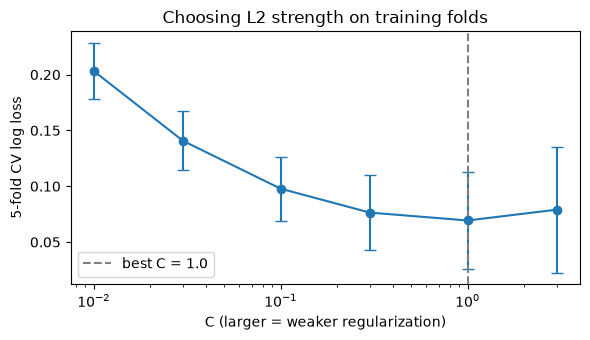

In [52]:
cv_table = pd.DataFrame(ours_cv, index=["mean CV log loss", "std"]).T.rename_axis("C")
print(cv_table.round(4).to_string())
print(f"best C = {best_C} (λ = 1/(C·n) ≈ {1 / (best_C * len(yc_tr) * 0.8):.4f} per fold)")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.errorbar(C_GRID, cv_table["mean CV log loss"], yerr=cv_table["std"], fmt="o-", capsize=4)
ax.axvline(best_C, ls="--", c="grey", label=f"best C = {best_C}")
ax.set(xscale="log", xlabel="C (larger = weaker regularization)", ylabel="5-fold CV log loss", title="Choosing L2 strength on training folds")
ax.legend()
plt.tight_layout()
plt.show()

### Step 2 — Fit the final model on the full training set and compare with scikit-learn

In [53]:
final_mu, final_sd = X_cancer[tr_idx].mean(axis=0), X_cancer[tr_idx].std(axis=0)


def scale_final(X):
    return (X - final_mu) / final_sd


screen_model = ScratchLogisticRegression(C=best_C).fit(scale_final(X_cancer[tr_idx]), yc_tr)
sk_screen = LogisticRegression(C=best_C, tol=1e-10, max_iter=10_000).fit(scale_final(X_cancer[tr_idx]), yc_tr)
assert np.allclose(screen_model.coef_, sk_screen.coef_[0], atol=1e-3)
p_val_screen = screen_model.predict_proba(scale_final(X_cancer[va_idx]))[:, 1]
assert np.allclose(p_val_screen, sk_screen.predict_proba(scale_final(X_cancer[va_idx]))[:, 1], atol=1e-3)
top = np.argsort(-np.abs(screen_model.coef_))[:5]
print("✅ from-scratch weights match sklearn LogisticRegression")
print("strongest features (standardized weight):", {str(cancer.feature_names[j]): round(float(screen_model.coef_[j]), 2) for j in top})

✅ from-scratch weights match sklearn LogisticRegression
strongest features (standardized weight): {'radius error': 1.09, 'worst texture': 1.01, 'worst concave points': 1.0, 'perimeter error': 0.94, 'mean concave points': 0.87}


### Step 3 — Choose the threshold on validation data

validation: 42 malignant | chosen threshold 0.07 → recall 1.000, precision 0.778
(at the default 0.50: recall 0.905, precision 0.950)


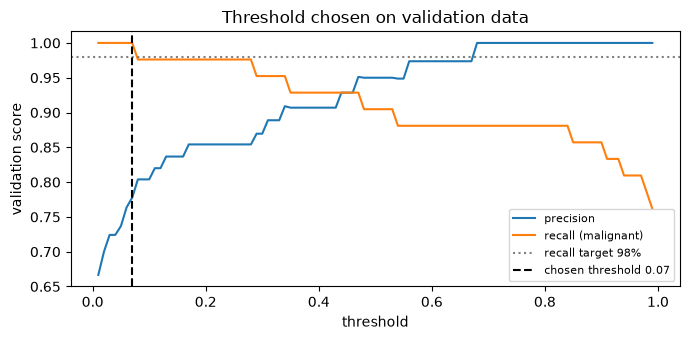

In [54]:
TARGET_RECALL = 0.98
val_precision, val_recall, val_f1 = metrics_at_thresholds(yc_va, p_val_screen)
meets = np.flatnonzero(val_recall >= TARGET_RECALL)
chosen_t = float(THRESHOLDS[meets.max()])                             # highest threshold still meeting the recall target
i_t = int(np.flatnonzero(THRESHOLDS == chosen_t)[0])
print(f"validation: {yc_va.sum()} malignant | chosen threshold {chosen_t:.2f} → recall {val_recall[i_t]:.3f}, precision {val_precision[i_t]:.3f}")
print(f"(at the default 0.50: recall {val_recall[THRESHOLDS == 0.5][0]:.3f}, precision {val_precision[THRESHOLDS == 0.5][0]:.3f})")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(THRESHOLDS, val_precision, label="precision")
ax.plot(THRESHOLDS, val_recall, label="recall (malignant)")
ax.axhline(TARGET_RECALL, ls=":", c="grey", label=f"recall target {TARGET_RECALL:.0%}")
ax.axvline(chosen_t, ls="--", c="black", label=f"chosen threshold {chosen_t:.2f}")
ax.set(xlabel="threshold", ylabel="validation score", title="Threshold chosen on validation data")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Step 4 — The one look at the test set

In [55]:
p_test_screen = screen_model.predict_proba(scale_final(X_cancer[te_idx]))[:, 1]
p_test_sk = sk_screen.predict_proba(scale_final(X_cancer[te_idx]))[:, 1]
n_mal = int(yc_te.sum())
report_rows = []
for label, probs in [("from scratch", p_test_screen), ("sklearn", p_test_sk)]:
    for t in [0.5, chosen_t]:
        counts = confusion_counts(yc_te, probs >= t)
        ci = binomtest(counts["TP"], n_mal).proportion_ci(confidence_level=0.95, method="wilson")
        report_rows.append({"model": label, "threshold": t, **counts, **basic_metrics(counts),
                            "recall 95% CI": f"{ci.low:.2f}–{ci.high:.2f}", "ROC-AUC": roc_auc_score(yc_te, probs),
                            "AP": average_precision_score(yc_te, probs), "Brier": brier_score_loss(yc_te, probs)})
test_report = pd.DataFrame(report_rows).set_index(["model", "threshold"])
print(f"TEST set: {len(yc_te)} tumours, {n_mal} malignant")
print(test_report.round(3).to_string())

ours_chosen = test_report.loc[("from scratch", chosen_t)]
assert (test_report.loc["from scratch"][["TP", "FP", "FN", "TN"]].to_numpy() == test_report.loc["sklearn"][["TP", "FP", "FN", "TN"]].to_numpy()).all()
print(f"\n✅ identical confusion counts for our model and sklearn's on test")
print(f"at threshold {chosen_t:.2f}: missed malignant = {ours_chosen['FN']}, false alarms = {ours_chosen['FP']};"
      f" recall target {TARGET_RECALL:.0%} {'met' if ours_chosen['recall'] >= TARGET_RECALL else 'NOT met'} on test")

TEST set: 113 tumours, 42 malignant
                        TP  FP  FN  TN  accuracy  precision  recall     f1 recall 95% CI  ROC-AUC     AP  Brier
model        threshold                                                                                         
from scratch 0.50       40   2   2  69     0.965      0.952   0.952  0.952     0.84–0.99    0.996  0.994  0.022
             0.07       42   8   0  63     0.929      0.840   1.000  0.913     0.92–1.00    0.996  0.994  0.022
sklearn      0.50       40   2   2  69     0.965      0.952   0.952  0.952     0.84–0.99    0.996  0.994  0.022
             0.07       42   8   0  63     0.929      0.840   1.000  0.913     0.92–1.00    0.996  0.994  0.022

✅ identical confusion counts for our model and sklearn's on test
at threshold 0.07: missed malignant = 0, false alarms = 8; recall target 98% met on test


**Stretch goals**
1. Replace the fixed recall target with a **cost** (e.g. a missed cancer = 20 false alarms) and pick the threshold minimizing validation cost — how different is it?
2. Tune C *and* the threshold together with **nested** cross-validation on train + validation, and compare the stability of the chosen threshold.
3. Train an **L1** logistic regression (proximal gradient: a gradient step, then `soft_threshold`) and report which features survive.
4. Plot a reliability curve for the screening model on validation data; would Platt scaling help?

### 🗣️ How to talk about this in an interview
- "I implemented L2 logistic regression with batch gradient descent, verified the gradient with finite differences, and matched scikit-learn's coefficients by mapping λ to C = 1/(λn)."
- "I split 60/20/20 stratified, tuned C by 5-fold CV **on the training set only** with the scaler fitted inside each fold, and chose the operating threshold on the validation set."
- "The business requirement was recall on the **malignant** class — sklearn encodes malignant as 0, so I made the positive class explicit to avoid silently reporting benign recall."
- "I picked the highest threshold that kept validation recall ≥ 98%, then evaluated **once** on test and reported recall with a Wilson confidence interval, because a test set with ~40 positives can't pin recall down precisely."
- "Next steps: cost-based threshold, calibration check, and nested CV to measure how stable the threshold choice is."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Explain the bias–variance trade-off. How do you tell which problem your model has?**

<details><summary>Show answer</summary>

- **30-second answer:** Expected error = bias² + variance + irreducible noise. Bias is error from overly simple assumptions (underfitting: train and validation both bad); variance is sensitivity to the particular training sample (overfitting: train good, validation much worse). More flexible models trade bias for variance. Diagnose by comparing train vs validation error and with learning curves.
- **Go deeper:** High bias → add features/capacity, reduce regularization; more data won't help (curves plateau together). High variance → more data, stronger regularization, simpler model, bagging/ensembles, early stopping. Modern over-parameterized deep nets show "double descent", but the train-vs-validation diagnosis still applies.
- **❌ Common wrong answer:** "Bias means the model is unfair and variance means the predictions are noisy" — mixing up statistical bias with fairness, or not connecting either to train/validation error.

</details>

**Q2. L1 vs L2 regularization — what's the difference and why does L1 give sparse weights?**

<details><summary>Show answer</summary>

- **30-second answer:** L2 adds α·Σw², shrinking all weights smoothly (closed form for linear regression, handles correlated features by sharing weight). L1 adds α·Σ|w|, which drives many weights to exactly zero — built-in feature selection. L1's pull toward zero is constant (α) even for tiny weights, so any weight whose data "support" is weaker than α is set to 0 (soft-thresholding); geometrically the L1 ball has corners on the axes.
- **Go deeper:** Bayesian view: L2 = Gaussian prior, L1 = Laplace prior. L1 isn't differentiable at 0, so it is solved with coordinate descent or proximal gradient. Among correlated features L1 picks one somewhat arbitrarily; **elastic net** mixes L1 and L2 to keep groups. Standardize features first.
- **❌ Common wrong answer:** "L1 is faster" or "L2 also sets weights to zero if α is large enough" (it only approaches zero).

</details>

**Q3. Why do we use cross-entropy (log loss) instead of MSE for classification?**

<details><summary>Show answer</summary>

- **30-second answer:** Log loss is the negative log-likelihood of a Bernoulli model, so minimizing it gives maximum-likelihood probabilities. For logistic regression it is convex, and its gradient is simply (p − y)·x. MSE on a sigmoid output is non-convex and its gradient contains p(1−p), which vanishes when the model is confidently wrong — learning stalls exactly when it should be fastest.
- **Go deeper:** Log loss heavily penalizes confident mistakes (−log 0.01 ≈ 4.6), which pushes toward honest probabilities; it is a *proper scoring rule* (so is the Brier score). In deep learning, softmax + cross-entropy has the same clean gradient (softmax − one-hot).
- **❌ Common wrong answer:** "MSE can't be used for classification" (it can — it just optimizes poorly and isn't the likelihood) or "cross-entropy is used because accuracy isn't differentiable" (true but not why cross-entropy over MSE).

</details>

**Q4. Precision vs recall — explain the trade-off with real examples.**

<details><summary>Show answer</summary>

- **30-second answer:** Precision = of the alarms, how many are real; recall = of the real cases, how many we caught. Raising the threshold usually raises precision and lowers recall. Cancer screening and fraud *detection* favour recall (a miss is expensive); a spam filter or auto-blocking payments favour precision (a false alarm hurts a real user); a fraud team that can review only 500 cases a day cares about precision in the top 500.
- **Go deeper:** Use F1 when both matter equally, F-β to weight recall β times as much, or better, an explicit cost matrix. Report the operating point (threshold) alongside the numbers, since precision and recall are meaningless without it.
- **❌ Common wrong answer:** Defining precision as TP / (TP + FN), or claiming you can maximize both by tuning the threshold.

</details>

**Q5. ROC-AUC or PR-AUC for a heavily imbalanced problem? Why?**

<details><summary>Show answer</summary>

- **30-second answer:** Prefer PR-AUC (average precision) when positives are rare and you care about them. ROC uses FPR = FP / (FP + TN); with a huge number of negatives, even many false positives barely move FPR, so ROC-AUC can look excellent while precision is poor. PR curves ignore true negatives and expose that. In section 10, ROC-AUC was above 0.9 while average precision was below 0.6.
- **Go deeper:** A random classifier has ROC-AUC 0.5 but PR-AUC ≈ the positive rate (0.023 for mammography), so always quote the baseline. ROC-AUC is still useful for comparing *rankings* and is insensitive to prevalence changes; PR-AUC changes when prevalence changes.
- **❌ Common wrong answer:** "ROC-AUC is biased by imbalance so it's wrong" — it's a valid ranking metric; it just answers a different question than "how precise are my alarms?"

</details>

**Q6. What is probability calibration, and when does it matter?**

<details><summary>Show answer</summary>

- **30-second answer:** A calibrated model's "70%" predictions are right about 70% of the time. It matters whenever the probability is used directly: expected-cost decisions, risk scores shown to people, bidding/ranking by expected value, combining models. Check with a reliability diagram and Brier score / log loss; fix with Platt scaling or isotonic regression fitted on held-out data.
- **Go deeper:** Class weights and resampling deliberately distort probabilities (our balanced model predicted 22% on average for a 2.3% event); boosted trees and modern deep nets are often over-confident (temperature scaling fixes nets). Calibration doesn't change ranking, so ROC-AUC stays the same. Isotonic needs more data than Platt and can overfit small sets.
- **❌ Common wrong answer:** "A model with high AUC is calibrated" or "just fit the calibrator on the training data" (it will look perfectly calibrated and not be).

</details>

**Q7. Gini impurity vs entropy for decision trees?**

<details><summary>Show answer</summary>

- **30-second answer:** Both measure node impurity and are 0 for pure nodes and maximal at 50/50. Gini = 1 − Σp²; entropy = −Σp·log₂p (information gain uses it). They choose the same split in the vast majority of cases; Gini is slightly faster (no logs) and is sklearn's default.
- **Go deeper:** Entropy is a bit more sensitive to changes in small class probabilities. Neither prevents overfitting — control that with `max_depth`, `min_samples_leaf`, `min_impurity_decrease`, or cost-complexity pruning (`ccp_alpha`). Trees don't need feature scaling.
- **❌ Common wrong answer:** "Entropy gives much better trees" or "Gini is for regression" (regression trees use variance/MSE reduction).

</details>

### 💻 Coding

**Q8. Implement ROC-AUC in NumPy without looping over pairs.**

<details><summary>Show answer</summary>

- **30-second answer:** Use ranks: `r = scipy.stats.rankdata(scores)` (average ranks for ties); `auc = (r[y==1].sum() - n_pos*(n_pos+1)/2) / (n_pos*n_neg)`. It's the Mann–Whitney U statistic: the probability a random positive outranks a random negative. O(n log n).
- **Go deeper:** The pairwise broadcast `(s_pos[:, None] > s_neg[None, :]).mean()` is correct but O(n_pos·n_neg) memory. Alternatively sort by score, sweep thresholds accumulating TP/FP, and integrate TPR over FPR with the trapezoid rule — handle tied scores as one threshold.
- **❌ Common wrong answer:** Computing AUC from hard 0/1 predictions, or ignoring ties.

</details>

**Q9. Write the training loop for logistic regression with L2 regularization.**

<details><summary>Show answer</summary>

- **30-second answer:** `for epoch in range(E): p = sigmoid(X @ w + b); grad_w = X.T @ (p - y) / n + lam * w; grad_b = (p - y).mean(); w -= lr * grad_w; b -= lr * grad_b`. Standardize X first, don't regularize b, use a numerically stable sigmoid and compute the loss with `logaddexp`.
- **Go deeper:** Verify with a finite-difference gradient check. Mention mini-batch SGD for large data, and that sklearn's `C` equals 1/(λn) for this mean-loss formulation. Newton's method (IRLS) converges in a handful of iterations for small feature counts.
- **❌ Common wrong answer:** `grad = X.T @ (y - p)` with `w -= lr * grad` (sign error → ascent), or penalizing the intercept.

</details>

### 🐛 Debugging Scenarios

**Q10. Validation AUC is 0.97, but in production the model performs like 0.70. Give concrete leakage causes you'd check.**

<details><summary>Show answer</summary>

- **30-second answer:** (1) Target leakage — a feature created after the outcome (e.g. "refund issued" to predict fraud). (2) Preprocessing, imputation, or feature selection fitted on all data before splitting / outside CV. (3) The same entity (patient, user, device) in both train and validation. (4) Random splits on time-ordered data — training on the future. (5) Duplicates or near-duplicates across splits. Then check train/production distribution shift and feature pipelines that differ between training and serving.
- **Go deeper:** Look for suspiciously strong single features (feature importance), rebuild splits by group/time, and wrap all preprocessing in a `Pipeline`. In section 14, selecting features on all rows produced a cross-validated AUC well above 0.5 on **pure noise**.
- **❌ Common wrong answer:** "The model is overfitting; add regularization" — overfitting shows up on validation; leakage hides from it.

</details>

**Q11. A teammate tried 200 hyperparameter settings and reports the best test-set accuracy. What's wrong, and how do you fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** Choosing the best of many options on the test set makes that score optimistically biased (the winner's curse) — the test set has become a validation set. Select on validation data or cross-validation, then evaluate the single chosen configuration once on an untouched test set.
- **Go deeper:** With small data use nested cross-validation (inner loop tunes, outer loop estimates). Section 2 measured the effect: the best of many simple rules scored higher on the set used to choose it than on fresh data in most splits.
- **❌ Common wrong answer:** "It's fine as long as we didn't train on the test set."

</details>

**Q12. Your fraud model has 99.5% accuracy but the fraud team says it's useless. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Fraud is rare (say 0.5%), so predicting "not fraud" for everyone already gives 99.5% accuracy. Check the confusion matrix and fraud-class recall/precision and PR-AUC; compare with the majority baseline. Then use class weights or resampling and choose the threshold on validation for the business cost or review capacity.
- **Go deeper:** Report precision@k (the team's daily review budget) and expected cost; stratify splits so every split has fraud cases; recalibrate if probabilities are consumed downstream.
- **❌ Common wrong answer:** "Collect more data" or "switch to a deep model" without changing the metric.

</details>

### 🏗️ Design

**Q13. How do you pick a classification threshold for a model going to production?**

<details><summary>Show answer</summary>

- **30-second answer:** Start from the decision: costs of false positives vs false negatives, or a capacity limit (e.g. 200 manual reviews a day), or a hard constraint (recall ≥ 98%). Sweep thresholds on validation (or out-of-fold) predictions, pick the one that optimizes that objective, confirm once on test, and monitor it in production because prevalence and score distributions drift.
- **Go deeper:** If probabilities are calibrated, the cost-optimal threshold is `cost_FP / (cost_FP + cost_FN)`. With small validation sets, report uncertainty (confidence intervals, bootstrap) and prefer out-of-fold predictions. scikit-learn's `TunedThresholdClassifierCV` automates the CV search.
- **❌ Common wrong answer:** "Use 0.5" or "pick the threshold with the best test F1."

</details>

**Q14. Design the evaluation plan for a model that flags high-risk patients from hospital records.**

<details><summary>Show answer</summary>

- **30-second answer:** Split by **patient** (and by time — train on earlier admissions, test on later ones) so no patient or future information leaks. Choose metrics tied to the clinical decision: recall at a fixed alert budget, precision/PPV, PR-AUC, calibration (reliability + Brier) because clinicians read the risk score. Tune on validation, test once, report confidence intervals and subgroup performance (age, sex, site).
- **Go deeper:** Audit features for target leakage (tests ordered *because* the doctor already suspected the outcome), run a silent "shadow" deployment before alerts go live, monitor drift and recalibrate periodically, and define who acts on an alert.
- **❌ Common wrong answer:** A random row-level split with accuracy as the headline metric.

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `precision_score([1, 1, 0, 0, 1], [1, 0, 1, 0, 1])`
<details><summary>Answer</summary>

`0.667` — three predicted positives (positions 0, 2, 4), two of them are real (0 and 4): 2/3.
</details>

**2.** `roc_auc_score([0, 0, 1, 1], [0.9, 0.8, 0.2, 0.1])`
<details><summary>Answer</summary>

`0.0` — every negative is scored above every positive: a perfectly *reversed* ranking (flip the scores and you get 1.0).
</details>

**3.** What are the coefficients of `Lasso(alpha=1e6).fit(X_diab, y_diab)`, and what does it predict?
<details><summary>Answer</summary>

All ten coefficients are exactly `0`, so it predicts the intercept — the mean of `y_diab` — for every patient. A huge L1 penalty makes every weight cost more than it helps.
</details>

**4.** You raise a classifier's threshold from 0.3 to 0.7. What can happen to recall?
(a) only increase or stay the same (b) only decrease or stay the same (c) either
<details><summary>Answer</summary>

**(b)** — a higher threshold can only turn predicted positives into negatives, so TP can't grow and recall = TP / (all positives) can't rise. Precision, by contrast, can move in either direction.
</details>

**5.** What is the Gini impurity of a node with 50 malignant and 50 benign tumours? And its entropy?
<details><summary>Answer</summary>

Gini `0.5` (1 − 0.25 − 0.25) and entropy `1.0` bit — both at their maximum for two classes.
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Cross-validation: evaluating estimator performance](https://scikit-learn.org/stable/modules/cross_validation.html) — k-fold, stratified, group, and time-series splits
- [scikit-learn — Metrics and scoring: quantifying the quality of predictions](https://scikit-learn.org/stable/modules/model_evaluation.html) — every metric in this notebook, with definitions
- [scikit-learn — Tuning the decision threshold for class prediction](https://scikit-learn.org/stable/modules/classification_threshold.html) — why 0.5 is arbitrary; `TunedThresholdClassifierCV`
- [scikit-learn — Probability calibration](https://scikit-learn.org/stable/modules/calibration.html) — reliability diagrams, Platt vs isotonic
- [scikit-learn — Common pitfalls and recommended practices](https://scikit-learn.org/stable/common_pitfalls.html) — data leakage and preprocessing inside a Pipeline
- [scikit-learn — Linear Models](https://scikit-learn.org/stable/modules/linear_model.html) and [Decision Trees](https://scikit-learn.org/stable/modules/tree.html) — the exact objectives behind `Ridge`, `Lasso`, `LogisticRegression`, and tree criteria

### 🎥 Videos
- [StatQuest — Machine Learning Fundamentals: Bias and Variance](https://www.youtube.com/watch?v=EuBBz3bI-aA) (6m36s) — Josh Starmer's short, visual intuition for under- vs overfitting; watch before section 7
- [StatQuest — ROC and AUC, Clearly Explained!](https://www.youtube.com/watch?v=4jRBRDbJemM) (16m17s) — builds the ROC curve one threshold at a time, exactly like our from-scratch version
- [StatQuest — Regularization Part 1: Ridge (L2) Regression](https://www.youtube.com/watch?v=Q81RR3yKn30) (20m26s) — why a penalty reduces variance; follow with his Lasso video for the L1 story

### 📄 Papers
- [Niculescu-Mizil & Caruana (2005) — Predicting Good Probabilities With Supervised Learning](https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf) — which models are miscalibrated and how Platt scaling and isotonic regression fix them
- [Saito & Rehmsmeier (2015) — The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0118432) — the evidence behind "use PR curves for rare positives"
- [Kapoor & Narayanan (2023) — Leakage and the Reproducibility Crisis in ML-based Science](https://arxiv.org/abs/2207.07048) — a taxonomy of leakage found in hundreds of published papers
- [Guo et al. (2017) — On Calibration of Modern Neural Networks](https://arxiv.org/abs/1706.04599) — why deep nets are over-confident; temperature scaling and expected calibration error

### 📘 Books & Courses
- [An Introduction to Statistical Learning](https://www.statlearning.com/) — free PDF (with a Python edition); chapters 2, 4, 5, 6, and 8 cover this notebook in depth
- [The Elements of Statistical Learning (2nd ed.)](https://hastie.su.domains/ElemStatLearn/) — the free, more mathematical companion (bias–variance, lasso, trees)
- [Google — Machine Learning Crash Course](https://developers.google.com/machine-learning/crash-course) — short modules on classification, thresholds, ROC, and regularization

### 🏋️ Practice
- [Kaggle — Data Leakage](https://www.kaggle.com/code/alexisbcook/data-leakage) — the leakage lesson from Kaggle Learn's Intermediate ML course, with an exercise
- [Deep-ML — Practice Machine Learning](https://www.deep-ml.com/) — interview-style problems implementing ML algorithms and metrics from scratch

## 📝 Summary Cheat Sheet

| Concept | What it does | Key formula / API |
|---|---|---|
| Splits | honest estimate of generalization | train (fit) · validation (choose) · test (report once); `stratify=y` |
| Losses | what training minimizes | MSE $r^2$ · MAE $\lvert r\rvert$ · Huber · log loss $-[y\log p+(1-y)\log(1-p)]$ |
| Logistic regression | probabilities from a linear score | $p=\sigma(w\cdot x+b)$ · $\nabla_w = X^\top(p-y)/n + \lambda w$ · sklearn `C = 1/(λn)` |
| Ridge (L2) | shrink weights smoothly | $w=(X^\top X+\alpha I)^{-1}X^\top y$ · `Ridge(alpha)` |
| Lasso (L1) | sparse weights | coordinate descent + soft-threshold · `Lasso(alpha)` |
| Bias–variance | diagnose under/overfitting | error = bias² + variance + noise · compare train vs validation · `learning_curve` |
| k-fold CV | stable validation, all preprocessing inside folds | `KFold`, `StratifiedKFold`, `GroupKFold`, `cross_val_score`, `Pipeline` |
| Confusion metrics | quality at one threshold | precision TP/(TP+FP) · recall TP/(TP+FN) · F1 = 2PR/(P+R) |
| ROC-AUC | ranking quality | P(score⁺ > score⁻) · `roc_auc_score` (from probabilities!) |
| PR-AUC / AP | ranking quality on rare positives | $\sum (R_n-R_{n-1})P_n$ · `average_precision_score` · baseline = prevalence |
| Imbalance | don't trust accuracy | class weights n/(2·n_c) · threshold tuned on validation · cost matrix |
| Calibration | probabilities you can trust | reliability curve · Brier $\overline{(p-y)^2}$ · Platt / isotonic on held-out data |
| Decision trees | greedy purest splits | Gini $1-\sum p^2$ · entropy $-\sum p\log_2 p$ · information gain · limit depth |
| Scaling | needed for gradients/distances/penalties | fit `StandardScaler` on train only · trees don't care |
| Leakage | validation lies | no future/target-derived features · group/time splits · selection inside CV |

## ➡️ What's Next

**[02 · Scikit-Learn](02_Scikit_Learn.ipynb)** — now that you know what every model, metric, and split is doing under the hood, learn to use scikit-learn's full toolkit productively: pipelines and `ColumnTransformer` for real messy tables, many more models, hyperparameter search, and model persistence.